# Yolo8 for counting cars facing front

In [ ]:
# Install YOLOv8 (Ultralytics)
!pip install ultralytics opencv-python matplotlib

import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
import os

# Load YOLOv8 pretrained model (use 'yolov8n.pt' for fastest, 'yolov8m.pt' for better accuracy)
model = YOLO("yolov8n.pt")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 7.5 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
import os
import cv2
from glob import glob

# Vehicle class IDs in COCO dataset
vehicle_classes = [2, 3, 5, 7]  # car=2, motorcycle=3, bus=5, truck=7

# Input and output folders
input_folder = "cars"
output_folder = "vehicle_crops"
os.makedirs(output_folder, exist_ok=True)

# Get all image files in the folder (common formats)
image_paths = glob(os.path.join(input_folder, "*.jpg")) + \
              glob(os.path.join(input_folder, "*.png")) + \
              glob(os.path.join(input_folder, "*.jpeg"))

crop_count = 0
target_size = (100, 90)  # (width, height)

for img_path in image_paths:
    img = cv2.imread(img_path)
    if img is None:
        continue  # skip if not a valid image

    # Run inference
    results = model(img)[0]

    # Process detected boxes
    for box in results.boxes:
        cls_id = int(box.cls[0].item())
        if cls_id in vehicle_classes:
            # Get bounding box
            x1, y1, x2, y2 = map(int, box.xyxy[0].tolist())

            # Crop vehicle
            crop = img[y1:y2, x1:x2]

            if crop.size == 0:  # skip invalid crops
                continue

            # Resize to fixed size
            crop_resized = cv2.resize(crop, target_size)

            # Create unique filename (include original image name)
            base_name = os.path.splitext(os.path.basename(img_path))[0]
            save_path = os.path.join(output_folder, f"{base_name}_vehicle_{crop_count}.jpg")

            cv2.imwrite(save_path, crop_resized)
            crop_count += 1

print(f"Saved {crop_count} vehicle crops (resized to {target_size}) to '{output_folder}/'")


0: 448x640 1 person, 19 cars, 8 buss, 2 trucks, 348.6ms
Speed: 6.9ms preprocess, 348.6ms inference, 36.0ms postprocess per image at shape (1, 3, 448, 640)

0: 384x640 3 persons, 16 cars, 6 buss, 1 truck, 163.2ms
Speed: 2.3ms preprocess, 163.2ms inference, 1.6ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 5 persons, 4 cars, 5 buss, 3 trucks, 2 umbrellas, 141.0ms
Speed: 2.1ms preprocess, 141.0ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 448x640 5 persons, 20 cars, 5 buss, 3 trucks, 171.3ms
Speed: 3.1ms preprocess, 171.3ms inference, 1.5ms postprocess per image at shape (1, 3, 448, 640)

0: 352x640 1 person, 25 cars, 9 buss, 1 truck, 138.6ms
Speed: 1.9ms preprocess, 138.6ms inference, 1.3ms postprocess per image at shape (1, 3, 352, 640)

0: 448x640 3 persons, 22 cars, 3 buss, 2 trucks, 159.0ms
Speed: 2.8ms preprocess, 159.0ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)

0: 384x640 14 cars, 1 bus, 2 trucks, 1 traffic light, 

In [ ]:
import zipfile
import os

folder_path = "vehicle_crops"
zip_filename = "vehicle_crops.zip"

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, folder_path)  # relative path inside zip
            zipf.write(file_path, arcname)

print(f"Created {zip_filename}")

Created vehicle_crops.zip


# Data preprocessing

In [ ]:
import zipfile
import os

# Path to your uploaded zip file
zip_path = "/content/vehicle_crops.zip"   # change to your zip file path

# Directory where files will be extracted
extract_dir = "/content/images"

# Create the directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Unzipped files are in:", extract_dir)

Unzipped files are in: /content/images


In [ ]:
import os
import glob

# Path to the extracted folder
extract_dir = "/content/images/vehicle_crops"   # change if needed

# Rename front images
front_files = sorted(glob.glob(os.path.join(extract_dir, "front*.jpg")))
for i, file_path in enumerate(front_files, start=1):
    new_name = os.path.join(extract_dir, f"front_{i}.jpg")
    os.rename(file_path, new_name)

# Rename back images
back_files = sorted(glob.glob(os.path.join(extract_dir, "back*.jpg")))
for i, file_path in enumerate(back_files, start=1):
    new_name = os.path.join(extract_dir, f"back_{i}.jpg")
    os.rename(file_path, new_name)

print("Renaming complete!")
print("Example renamed files:")
print(glob.glob(os.path.join(extract_dir, "*.jpg"))[:10])  # show first 10

Renaming complete!
Example renamed files:
['/content/images/vehicle_crops/back_143.jpg', '/content/images/vehicle_crops/front_139.jpg', '/content/images/vehicle_crops/front_476.jpg', '/content/images/vehicle_crops/back_59.jpg', '/content/images/vehicle_crops/front_291.jpg', '/content/images/vehicle_crops/front_125.jpg', '/content/images/vehicle_crops/back_387.jpg', '/content/images/vehicle_crops/back_468.jpg', '/content/images/vehicle_crops/back_295.jpg', '/content/images/vehicle_crops/front_271.jpg']


In [ ]:
import zipfile
import os

folder_path = "/content/images/vehicle_crops"
zip_filename = "dataset.zip"

with zipfile.ZipFile(zip_filename, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, _, files in os.walk(folder_path):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, folder_path)  # relative path inside zip
            zipf.write(file_path, arcname)

print(f"Created {zip_filename}")

Created dataset.zip


# Training front/back binary classification

In [ ]:
import zipfile
import os

# Path to your uploaded zip file
zip_path = "/content/dataset.zip"   # change to your zip file path

# Directory where files will be extracted
extract_dir = "/content/dataset"

# Create the directory if it doesn't exist
os.makedirs(extract_dir, exist_ok=True)

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Unzipped files are in:", extract_dir)

Unzipped files are in: /content/dataset


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

# Path to dataset folder
data_dir = "/content/dataset/dataset (1)"

# Create dataset from folder
# TensorFlow will automatically label "back" as 0, "front" as 1 if placed in subfolders
# Let's move them into subfolders for clarity

import os, shutil, glob

# Organize into subfolders
front_dir = os.path.join(data_dir, "front")
back_dir = os.path.join(data_dir, "back")
os.makedirs(front_dir, exist_ok=True)
os.makedirs(back_dir, exist_ok=True)

for f in glob.glob(os.path.join(data_dir, "front*.jpg")):
    shutil.move(f, front_dir)
for f in glob.glob(os.path.join(data_dir, "back*.jpg")):
    shutil.move(f, back_dir)

# Load training and validation datasets
img_size = (100, 90)
batch_size = 32

train_ds = keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.1,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

val_ds = keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.1,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size
)

# Normalize pixel values [0,1]
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

# Prefetch for performance
train_ds = train_ds.prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=tf.data.AUTOTUNE)

# Define CNN model
model = keras.Sequential([
    layers.Conv2D(32, (3,3), activation="relu", input_shape=(100,90,3)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")  # binary classification
])

# Compile model
model.compile(optimizer="adam",
              loss="binary_crossentropy",
              metrics=["accuracy"])

# Train model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100
)

Found 1114 files belonging to 2 classes.
Using 1003 files for training.
Found 1114 files belonging to 2 classes.
Using 111 files for validation.
Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.6083 - loss: 0.6485 - val_accuracy: 0.8108 - val_loss: 0.4347
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.8137 - loss: 0.4149 - val_accuracy: 0.8649 - val_loss: 0.3605
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8647 - loss: 0.3335 - val_accuracy: 0.8468 - val_loss: 0.3419
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9138 - loss: 0.2418 - val_accuracy: 0.8378 - val_loss: 0.4218
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9049 - loss: 0.2508 - val_accuracy: 0.8919 - val_loss: 0.3038
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9401 - loss: 0.1689 - val_accuracy: 0.8829 - val_loss: 0.3144
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9398 - loss: 0.1551

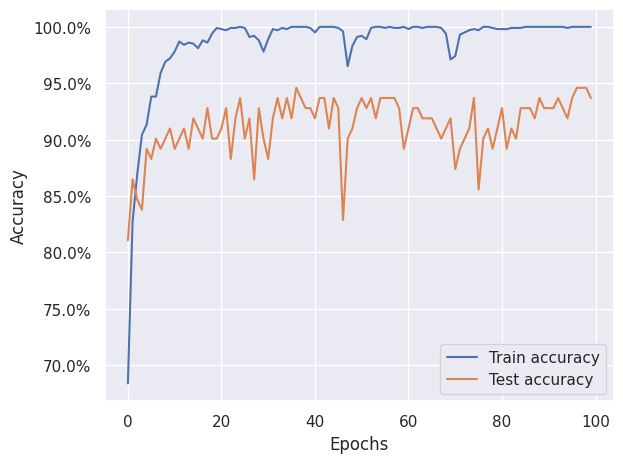

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns

sns.set()

plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Test accuracy")

# Format y-axis as %
plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
# (1.0 means the values are in [0,1]; use 100 if already in [0,100])

plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.savefig("training_results.png", dpi=300)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


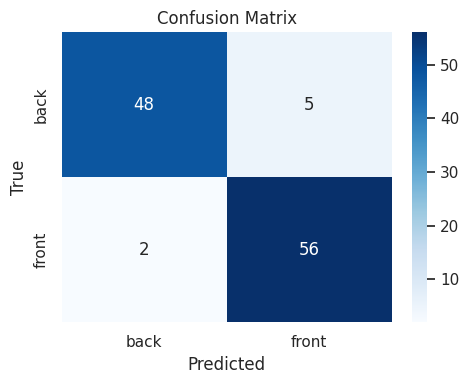

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Get true labels and predictions from validation set
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    preds = (preds > 0.5).astype(int)  # convert probabilities to 0/1
    y_true.extend(labels.numpy())
    y_pred.extend(preds.flatten())

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)
class_names = ["back", "front"]

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion.png", dpi=300)
plt.show()



In [ ]:
# Classification report (precision, recall, F1)
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        back       0.96      0.91      0.93        53
       front       0.92      0.97      0.94        58

    accuracy                           0.94       111
   macro avg       0.94      0.94      0.94       111
weighted avg       0.94      0.94      0.94       111



In [ ]:
# Save full model
model.save("/content/car_orientation_classifier.h5")

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.1 MB/s eta 0:00:00


In [ ]:
from ultralytics import YOLO
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import cv2
import numpy as np
from tensorflow.keras.utils import img_to_array, load_img


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.



0: 352x640 29 cars, 3 trucks, 71.0ms
Speed: 3.3ms preprocess, 71.0ms inference, 2.1ms postprocess per image at shape (1, 3, 352, 640)


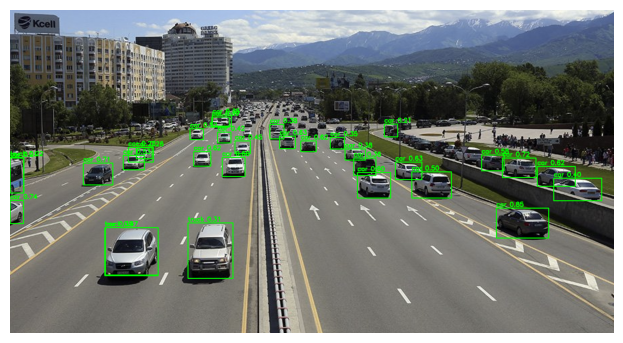

Vehicles detected: 32


In [ ]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load YOLOv8 model
model = YOLO("yolov8n.pt")

# Load image
image_path = "/content/carsss.png"
img = cv2.imread(image_path)

# Run YOLO detection
results = model.predict(img, conf=0.2)

# Define COCO vehicle classes
vehicle_classes = [2, 3, 5, 7]
# 2 = car, 3 = motorcycle, 5 = bus, 7 = truck

# Get boxes only for vehicles
boxes = []
for box in results[0].boxes:
    cls_id = int(box.cls[0])
    if cls_id in vehicle_classes:
        boxes.append(box)

# Draw bounding boxes manually for vehicles
annotated_frame = img.copy()
for box in boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])  # bounding box coordinates
    label = results[0].names[int(box.cls[0])]
    conf = float(box.conf[0])

    # Draw rectangle
    cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    # Put label
    cv2.putText(annotated_frame, f"{label} {conf:.2f}", (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

# Show image
plt.figure()
plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.tight_layout()
plt.savefig("bounded_cars.png", dpi=300)
plt.show()

# Print vehicle count
print(f"Vehicles detected: {len(boxes)}")


0: 352x640 29 cars, 3 trucks, 18.2ms
Speed: 2.8ms preprocess, 18.2ms inference, 2.2ms postprocess per image at shape (1, 3, 352, 640)


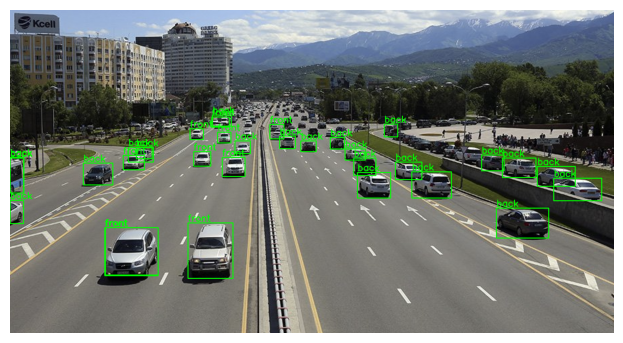

Vehicles detected: 32


In [ ]:
from ultralytics import YOLO
import tensorflow as tf
from tensorflow import keras
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Load Models
# ---------------------------
yolo_model = YOLO("yolov8n.pt")  # YOLO for vehicle detection
orientation_model = keras.models.load_model("/content/car_orientation_classifier.h5")  # Binary classifier

# ---------------------------
# Settings
# ---------------------------
image_path = "/content/carsss.png"
img_size = (100, 90)

# COCO vehicle classes
vehicle_classes = [2, 3, 5, 7]
# 2 = car, 3 = motorcycle, 5 = bus, 7 = truck

# ---------------------------
# Orientation Classifier
# ---------------------------
def classify_crop(crop):
    crop_resized = cv2.resize(crop, img_size)
    crop_array = crop_resized.astype("float32") / 255.0
    crop_array = np.expand_dims(crop_array, axis=0)
    pred = orientation_model.predict(crop_array, verbose=0)[0][0]
    return "front" if pred > 0.95 else "back"

# ---------------------------
# Run YOLO Detection
# ---------------------------
img = cv2.imread(image_path)
results = yolo_model.predict(img, conf=0.2) # higher iou keeps more boxes

# Get only vehicles
boxes = []
for box in results[0].boxes:
    cls_id = int(box.cls[0])
    if cls_id in vehicle_classes:
        boxes.append(box)

# ---------------------------
# Draw bounding boxes + classify orientation
# ---------------------------
annotated_frame = img.copy()
for box in boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    cls_id = int(box.cls[0])


    crop = img[y1:y2, x1:x2]
    label = classify_crop(crop)  # "front" or "back"


    # Draw rectangle + label
    cv2.rectangle(annotated_frame, (x1, y1), (x2, y2), (0, 255, 0), 2)
    cv2.putText(annotated_frame, label, (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

# ---------------------------
# Show Result
# ---------------------------
plt.figure()
plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.tight_layout()
plt.savefig("result.png", dpi=300)
plt.show()

print(f"Vehicles detected: {len(boxes)}")

In [ ]:
# 1. Install SUMO
!apt-get install -y sumo sumo-tools sumo-doc > /dev/null 2>&1
!pip install traci

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.4/278.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.1/278.1 kB 13.5 MB/s eta 0:00:00


In [ ]:
# =========================
# 🚦 Full SUMO Simulation in Colab (One Intersection)
# =========================



# 2. Create nodes and edges for a 4-way intersection
nodes_xml = """<nodes>
    <node id="north" x="100" y="200" type="priority"/>
    <node id="south" x="100" y="0" type="priority"/>
    <node id="east"  x="200" y="100" type="priority"/>
    <node id="west"  x="0"   y="100" type="priority"/>
    <node id="center" x="100" y="100" type="traffic_light"/>
</nodes>
"""
with open("cross.nod.xml", "w") as f:
    f.write(nodes_xml)

edges_xml = """<edges>
    <edge id="north_in" from="north" to="center"/>
    <edge id="south_in" from="south" to="center"/>
    <edge id="east_in"  from="east"  to="center"/>
    <edge id="west_in"  from="west"  to="center"/>
    <edge id="north_out" from="center" to="north"/>
    <edge id="south_out" from="center" to="south"/>
    <edge id="east_out"  from="center" to="east"/>
    <edge id="west_out"  from="center" to="west"/>
</edges>
"""
with open("cross.edg.xml", "w") as f:
    f.write(edges_xml)

# 3. Build network
!netconvert -n cross.nod.xml -e cross.edg.xml -o cross.net.xml > /dev/null 2>&1

# 4. Define routes (vehicles flowing randomly from each direction)
routes_xml = """<routes>
    <vType id="car" accel="2.6" decel="4.5" sigma="0.5" length="5" maxSpeed="16.7"/>

    <flow id="north_south" type="car" begin="0" end="200" probability="0.2" from="north_in" to="south_out"/>
    <flow id="south_north" type="car" begin="0" end="200" probability="0.2" from="south_in" to="north_out"/>
    <flow id="east_west" type="car" begin="0" end="200" probability="0.2" from="east_in" to="west_out"/>
    <flow id="west_east" type="car" begin="0" end="200" probability="0.2" from="west_in" to="east_out"/>
</routes>
"""
with open("cross.rou.xml", "w") as f:
    f.write(routes_xml)

# 5. Simulation configuration
config_xml = """<configuration>
    <input>
        <net-file value="cross.net.xml"/>
        <route-files value="cross.rou.xml"/>
    </input>
    <time>
        <begin value="0"/>
        <end value="200"/>
    </time>
</configuration>
"""
with open("cross.sumocfg", "w") as f:
    f.write(config_xml)

# 6. Run simulation with TraCI
import traci

print("Starting SUMO...")
traci.start(["sumo", "-c", "cross.sumocfg", "--step-length", "1"])

for step in range(50):  # simulate 50 seconds
    traci.simulationStep()

    # Example: check how many cars are on each incoming edge
    north = traci.edge.getLastStepVehicleNumber("north_in")
    south = traci.edge.getLastStepVehicleNumber("south_in")
    east  = traci.edge.getLastStepVehicleNumber("east_in")
    west  = traci.edge.getLastStepVehicleNumber("west_in")

    print(f"Step {step:02d} | N:{north} S:{south} E:{east} W:{west}")

traci.close()
print("Simulation finished ✅")

/bin/bash: line 1:  3355 Segmentation fault      (core dumped) netconvert -n cross.nod.xml -e cross.edg.xml -o cross.net.xml > /dev/null 2>&1
Starting SUMO...
 Retrying in 1 seconds
Step 00 | N:0 S:0 E:1 W:0
Step 01 | N:0 S:1 E:1 W:0
Step 02 | N:0 S:1 E:1 W:0
Step 03 | N:0 S:1 E:2 W:0
Step 04 | N:1 S:1 E:2 W:0
Step 05 | N:1 S:1 E:2 W:0
Step 06 | N:1 S:1 E:2 W:0
Step 07 | N:2 S:1 E:3 W:0
Step 08 | N:2 S:2 E:3 W:1
Step 09 | N:2 S:2 E:3 W:1
Step 10 | N:2 S:2 E:4 W:1
Step 11 | N:3 S:1 E:4 W:2
Step 12 | N:3 S:1 E:4 W:2
Step 13 | N:3 S:1 E:4 W:2
Step 14 | N:3 S:1 E:5 W:2
Step 15 | N:3 S:1 E:5 W:3
Step 16 | N:3 S:1 E:5 W:3
Step 17 | N:3 S:1 E:6 W:3
Step 18 | N:3 S:0 E:6 W:4
Step 19 | N:3 S:1 E:6 W:4
Step 20 | N:4 S:1 E:6 W:4
Step 21 | N:3 S:1 E:6 W:5
Step 22 | N:3 S:1 E:6 W:5
Step 23 | N:4 S:1 E:7 W:5
Step 24 | N:3 S:1 E:7 W:5
Step 25 | N:3 S:1 E:7 W:5
Step 26 | N:4 S:1 E:7 W:5
Step 27 | N:3 S:1 E:7 W:5
Step 28 | N:3 S:1 E:7 W:6
Step 29 | N:4 S:1 E:7 W:6
Step 30 | N:3 S:1 E:7 W:6
Step 31 | N:

In [ ]:
if traci.isLoaded():
    traci.close()

/bin/bash: line 1:  3382 Segmentation fault      (core dumped) netconvert -n cross.nod.xml -e cross.edg.xml -o cross.net.xml > /dev/null 2>&1
 Retrying in 1 seconds


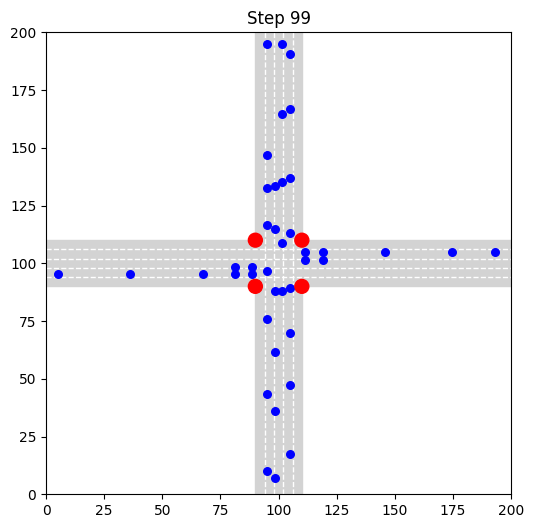

In [ ]:
# 2. Create nodes and edges for a 4-way intersection
nodes_xml = """<nodes>
    <node id="north" x="100" y="200" type="priority"/>
    <node id="south" x="100" y="0" type="priority"/>
    <node id="east"  x="200" y="100" type="priority"/>
    <node id="west"  x="0"   y="100" type="priority"/>
    <node id="center" x="100" y="100" type="traffic_light"/>
</nodes>
"""
with open("cross.nod.xml", "w") as f:
    f.write(nodes_xml)

edges_xml = """<edges>
    <edge id="north_in" from="north" to="center" numLanes="2" speed="16.7"/>
    <edge id="south_in" from="south" to="center" numLanes="2" speed="16.7"/>
    <edge id="east_in"  from="east"  to="center" numLanes="2" speed="16.7"/>
    <edge id="west_in"  from="west"  to="center" numLanes="2" speed="16.7"/>

    <edge id="north_out" from="center" to="north" numLanes="2" speed="16.7"/>
    <edge id="south_out" from="center" to="south" numLanes="2" speed="16.7"/>
    <edge id="east_out"  from="center" to="east" numLanes="2" speed="16.7"/>
    <edge id="west_out"  from="center" to="west" numLanes="2" speed="16.7"/>
</edges>
"""
with open("cross.edg.xml", "w") as f:
    f.write(edges_xml)

# 3. Build network
!netconvert -n cross.nod.xml -e cross.edg.xml -o cross.net.xml > /dev/null 2>&1

# 4. Define routes
routes_xml = """<routes>
    <vType id="car" accel="2.6" decel="4.5" sigma="0.5" length="5" maxSpeed="16.7"/>

    <flow id="north_south" type="car" begin="0" end="100" probability="0.2" from="north_in" to="south_out"/>
    <flow id="south_north" type="car" begin="0" end="100" probability="0.2" from="south_in" to="north_out"/>
    <flow id="east_west" type="car" begin="0" end="100" probability="0.2" from="east_in" to="west_out"/>
    <flow id="west_east" type="car" begin="0" end="100" probability="0.2" from="west_in" to="east_out"/>
</routes>
"""
with open("cross.rou.xml", "w") as f:
    f.write(routes_xml)

# 5. Config
config_xml = """<configuration>
    <input>
        <net-file value="cross.net.xml"/>
        <route-files value="cross.rou.xml"/>
    </input>
    <time>
        <begin value="0"/>
        <end value="100"/>
    </time>
</configuration>
"""
with open("cross.sumocfg", "w") as f:
    f.write(config_xml)

# 6. Run simulation & collect vehicle positions and traffic light states
import traci

traci.start(["sumo", "-c", "cross.sumocfg", "--step-length", "1"])

vehicle_positions = []
traffic_lights = []
for step in range(100):
    traci.simulationStep()
    positions = []
    for vid in traci.vehicle.getIDList():
        x, y = traci.vehicle.getPosition(vid)
        positions.append((x, y))
    vehicle_positions.append(positions)

    # get traffic light state
    tl_state = traci.trafficlight.getRedYellowGreenState("center")
    traffic_lights.append(tl_state)

traci.close()

# 7. Animate with matplotlib
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# --- Helper to draw intersection background (roads + lanes) ---
def draw_intersection(ax):
    road_color = "lightgray"
    lane_color = "white"

    # Vertical road
    ax.add_patch(plt.Rectangle((90, 0), 20, 200, color=road_color, zorder=0))
    # Horizontal road
    ax.add_patch(plt.Rectangle((0, 90), 200, 20, color=road_color, zorder=0))

    # Lane dividers (vertical)
    for offset in [-6, -2, 2, 6]:
        ax.plot([100+offset, 100+offset], [0, 200],
                color=lane_color, linestyle="--", linewidth=1, zorder=1)

    # Lane dividers (horizontal)
    for offset in [-6, -2, 2, 6]:
        ax.plot([0, 200], [100+offset, 100+offset],
                color=lane_color, linestyle="--", linewidth=1, zorder=1)

# --- Plot setup ---
fig, ax = plt.subplots(figsize=(6,6))
ax.set_xlim(0, 200)
ax.set_ylim(0, 200)

draw_intersection(ax)

scat = ax.scatter([], [], c="blue", s=30)
# traffic lights as circles
tl_artists = [
    ax.add_patch(plt.Circle((110,110), 3, color="red")),
    ax.add_patch(plt.Circle((90,110), 3, color="red")),
    ax.add_patch(plt.Circle((110,90), 3, color="red")),
    ax.add_patch(plt.Circle((90,90), 3, color="red")),
]

def update(frame):
    # update vehicles
    data = vehicle_positions[frame]
    if data:
        xs, ys = zip(*data)
    else:
        xs, ys = [], []
    scat.set_offsets(list(zip(xs, ys)))

    # update traffic lights (simple coloring)
    state = traffic_lights[frame]
    # State string looks like "GrGr" etc (N,E,S,W ordering)
    colors = {"G":"green", "r":"red", "y":"yellow"}
    for i, circle in enumerate(tl_artists):
        circle.set_color(colors.get(state[i].lower(), "red"))

    ax.set_title(f"Step {frame}")
    return scat, *tl_artists

ani = animation.FuncAnimation(fig, update, frames=len(vehicle_positions), interval=200, blit=True)

from IPython.display import HTML
HTML(ani.to_jshtml())

In [ ]:
if traci.isLoaded():
    traci.close()

In [ ]:
import os
import traci
import pandas as pd

# Set SUMO binary (switch to sumo-gui if you want visualization)
sumo_binary = "/usr/bin/sumo"
sumo_cmd = [sumo_binary, "-c", "cross.sumocfg"]

# Run simulation
try:
    traci.start(sumo_cmd)
    step = 0

    # Track cumulative urgency for averaging
    ns_urgency_total, ew_urgency_total = 0, 0
    steps_with_data = 0

    # Waiting time accumulators
    waiting_times = {'north_in_0': 0, 'south_in_0': 0, 'east_in_0': 0, 'west_in_0': 0}

    while step < 300:  # run for 300 simulation steps
        traci.simulationStep()

        # Vehicle counts on each incoming lane
        north = len(traci.lane.getLastStepVehicleIDs("north_in_0"))
        south = len(traci.lane.getLastStepVehicleIDs("south_in_0"))
        east  = len(traci.lane.getLastStepVehicleIDs("east_in_0"))
        west  = len(traci.lane.getLastStepVehicleIDs("west_in_0"))

        # Current light phase
        current_phase = traci.trafficlight.getPhase("center")

        # Update waiting times (increment only if lane is red)
        if current_phase in [2, 3]:  # EW green, NS red
            waiting_times['north_in_0'] += north
            waiting_times['south_in_0'] += south
            waiting_times['east_in_0'] = 0
            waiting_times['west_in_0'] = 0
        else:  # NS green, EW red
            waiting_times['east_in_0'] += east
            waiting_times['west_in_0'] += west
            waiting_times['north_in_0'] = 0
            waiting_times['south_in_0'] = 0

        # Clearance urgency index (vehicles + 0.1 * waiting time)
        ns_urgency = (north + south) + 0.1 * (waiting_times['north_in_0'] + waiting_times['south_in_0'])
        ew_urgency = (east + west)   + 0.1 * (waiting_times['east_in_0'] + waiting_times['west_in_0'])

        print(f"Step {step}: NS_Urgency={ns_urgency:.2f}, EW_Urgency={ew_urgency:.2f}")

        # Update totals
        ns_urgency_total += ns_urgency
        ew_urgency_total += ew_urgency
        steps_with_data += 1

        # --- Example adaptive control (replace with LLM later) ---
        if ns_urgency > ew_urgency:
            if current_phase in [2, 3]:
                traci.trafficlight.setPhase("center", 0)
        else:
            if current_phase in [0, 1]:
                traci.trafficlight.setPhase("center", 2)

        step += 1

finally:
    traci.close()

# Print average clearance urgency index
avg_ns = ns_urgency_total / steps_with_data
avg_ew = ew_urgency_total / steps_with_data
print(f"\n=== Average Clearance Urgency Index ===")
print(f"North-South: {avg_ns:.2f}")
print(f"East-West : {avg_ew:.2f}")

 Retrying in 1 seconds
Step 0: NS_Urgency=0.00, EW_Urgency=1.10
Step 1: NS_Urgency=1.10, EW_Urgency=1.00
Step 2: NS_Urgency=1.00, EW_Urgency=1.10
Step 3: NS_Urgency=1.10, EW_Urgency=2.00
Step 4: NS_Urgency=2.30, EW_Urgency=2.00
Step 5: NS_Urgency=2.00, EW_Urgency=2.20
Step 6: NS_Urgency=2.20, EW_Urgency=2.00
Step 7: NS_Urgency=3.00, EW_Urgency=3.30
Step 8: NS_Urgency=4.40, EW_Urgency=4.00
Step 9: NS_Urgency=4.00, EW_Urgency=4.40
Step 10: NS_Urgency=4.40, EW_Urgency=4.00
Step 11: NS_Urgency=4.00, EW_Urgency=5.50
Step 12: NS_Urgency=4.40, EW_Urgency=5.00
Step 13: NS_Urgency=4.80, EW_Urgency=4.00
Step 14: NS_Urgency=5.00, EW_Urgency=5.50
Step 15: NS_Urgency=5.50, EW_Urgency=6.00
Step 16: NS_Urgency=4.90, EW_Urgency=6.00
Step 17: NS_Urgency=6.40, EW_Urgency=6.00
Step 18: NS_Urgency=3.00, EW_Urgency=7.70
Step 19: NS_Urgency=4.40, EW_Urgency=6.00
Step 20: NS_Urgency=5.90, EW_Urgency=6.00
Step 21: NS_Urgency=6.40, EW_Urgency=5.00
Step 22: NS_Urgency=5.00, EW_Urgency=5.50
Step 23: NS_Urgency=6

In [ ]:
if traci.isLoaded():
    traci.close()

In [ ]:
# =========================
# 🚦 SUMO: Test Traffic-Light Strategies vs Clearance Urgency
# =========================

# 0) Install SUMO (Colab)
!apt-get install -y sumo sumo-tools sumo-doc > /dev/null 2>&1

# 1) Build a minimal 4-way intersection network (nodes + edges)
nodes_xml = """<nodes>
    <node id="north" x="100" y="200" type="priority"/>
    <node id="south" x="100" y="0"   type="priority"/>
    <node id="east"  x="200" y="100" type="priority"/>
    <node id="west"  x="0"   y="100" type="priority"/>
    <node id="center" x="100" y="100" type="traffic_light"/>
</nodes>
"""
with open("cross.nod.xml", "w") as f: f.write(nodes_xml)

edges_xml = """<edges>
    <edge id="north_in" from="north" to="center"/>
    <edge id="south_in" from="south" to="center"/>
    <edge id="east_in"  from="east"  to="center"/>
    <edge id="west_in"  from="west"  to="center"/>
    <edge id="north_out" from="center" to="north"/>
    <edge id="south_out" from="center" to="south"/>
    <edge id="east_out"  from="center" to="east"/>
    <edge id="west_out"  from="center" to="west"/>
</edges>
"""
with open("cross.edg.xml", "w") as f: f.write(edges_xml)

# Build the network
!netconvert -n cross.nod.xml -e cross.edg.xml -o cross.net.xml > /dev/null 2>&1

# 2) Define routes (random flows from each approach)
routes_xml = """<routes>
    <vType id="car" accel="2.6" decel="4.5" sigma="0.5" length="5" maxSpeed="16.7"/>
    <!-- Probability per second of a new vehicle entering that O-D path -->
    <flow id="n_s" type="car" begin="0" end="600" probability="0.25" from="north_in" to="south_out"/>
    <flow id="s_n" type="car" begin="0" end="600" probability="0.25" from="south_in" to="north_out"/>
    <flow id="e_w" type="car" begin="0" end="600" probability="0.25" from="east_in"  to="west_out"/>
    <flow id="w_e" type="car" begin="0" end="600" probability="0.25" from="west_in"  to="east_out"/>
</routes>
"""
with open("cross.rou.xml", "w") as f: f.write(routes_xml)

# 3) Simulation config
config_xml = """<configuration>
    <input>
        <net-file value="cross.net.xml"/>
        <route-files value="cross.rou.xml"/>
    </input>
    <time>
        <begin value="0"/>
        <end value="600"/>
    </time>
</configuration>
"""
with open("cross.sumocfg", "w") as f: f.write(config_xml)

# 4) Python control & experiments
import traci
import statistics

IN_LANES = ["north_in_0", "south_in_0", "east_in_0", "west_in_0"]
NS_LANES = ["north_in_0", "south_in_0"]
EW_LANES = ["east_in_0", "west_in_0"]

def lane_counts_and_wait():
    """Return (counts, waits) dict for each incoming lane.
       counts = number of vehicles on lane this step
       waits  = total halting/waiting seconds on that lane (SUMO aggregates per step)
    """
    counts, waits = {}, {}
    for ln in IN_LANES:
        counts[ln] = len(traci.lane.getLastStepVehicleIDs(ln))
        waits[ln]  = traci.lane.getWaitingTime(ln)  # total seconds of halting time for vehicles on this lane (this step)
    return counts, waits

def compute_cui(alpha, beta, counts, waits):
    """Compute Clearance Urgency Index for NS and EW approaches."""
    ns_count = sum(counts[ln] for ln in NS_LANES)
    ew_count = sum(counts[ln] for ln in EW_LANES)
    ns_wait  = sum(waits[ln]  for ln in NS_LANES)
    ew_wait  = sum(waits[ln]  for ln in EW_LANES)
    ns_cui = alpha * ns_count + beta * ns_wait
    ew_cui = alpha * ew_count + beta * ew_wait
    return ns_cui, ew_cui, ns_count, ew_count

def get_tl_id():
    tls = traci.trafficlight.getIDList()
    if not tls:
        raise RuntimeError("No traffic light found")
    return tls[0]

def extend_current_green(tl_id):
    """Keep current green phase alive by setting remaining duration to 1s repeatedly."""
    traci.trafficlight.setPhaseDuration(tl_id, 1)

def switch_from_NS_to_EW(tl_id, yellow=3):
    # Phase 0: NS green -> Phase 1: NS yellow -> auto -> Phase 2: EW green
    traci.trafficlight.setPhase(tl_id, 1)            # NS yellow
    traci.trafficlight.setPhaseDuration(tl_id, yellow)

def switch_from_EW_to_NS(tl_id, yellow=3):
    # Phase 2: EW green -> Phase 3: EW yellow -> auto -> Phase 0: NS green
    traci.trafficlight.setPhase(tl_id, 3)            # EW yellow
    traci.trafficlight.setPhaseDuration(tl_id, yellow)

def run_sim(strategy, alpha=1.0, beta=0.1, min_green=10, max_green=45, delta=0.25, yellow=3, sim_steps=600):
    """Run one simulation with a chosen strategy.
       strategy in {"fixed","actuated_cui","threshold_cui"}.
    """
    traci.start(["sumo", "-c", "cross.sumocfg", "--step-length", "1"])
    tl_id = get_tl_id()
    step = 0

    # Metrics
    ns_cui_sum = ew_cui_sum = 0.0
    ns_cnt_sum = ew_cnt_sum = 0
    steps_counted = 0
    arrived_count = 0
    time_loss_list = []

    # Actuated bookkeeping
    green_elapsed = 0  # seconds in current green
    last_phase = traci.trafficlight.getPhase(tl_id)  # 0: NS G, 2: EW G (typically)
    # if not starting on green, push to NS green (phase 0)
    if last_phase not in (0,2):
        traci.trafficlight.setPhase(tl_id, 0)
        traci.trafficlight.setPhaseDuration(tl_id, min_green)
        last_phase = 0

    while step < sim_steps:
        traci.simulationStep()

        # Collect arrivals & their time loss at this step
        arrived = traci.simulation.getArrivedIDList()
        arrived_count += len(arrived)
        for vid in arrived:
            # total time loss accrued by this vehicle during its trip
            try:
                tloss = traci.vehicle.getTimeLoss(vid)
                time_loss_list.append(tloss)
            except traci.TraCIException:
                pass

        counts, waits = lane_counts_and_wait()
        ns_cui, ew_cui, ns_cnt, ew_cnt = compute_cui(alpha, beta, counts, waits)
        ns_cui_sum += ns_cui
        ew_cui_sum += ew_cui
        ns_cnt_sum += ns_cnt
        ew_cnt_sum += ew_cnt
        steps_counted += 1

        phase = traci.trafficlight.getPhase(tl_id)

        if strategy == "fixed":
            # Let SUMO's default fixed program run (do nothing)
            pass

        else:
            # We assume two green phases: 0 (NS G) and 2 (EW G). Keep green alive, then decide switching.
            if phase == 0:  # NS green
                green_elapsed = green_elapsed + 1 if last_phase == 0 else 1
                last_phase = 0
                extend_current_green(tl_id)

                if strategy == "actuated_cui":
                    # switch if competitor is significantly larger OR max green reached, but honor min green
                    if green_elapsed >= min_green and (ew_cui > ns_cui) or green_elapsed >= max_green:
                        switch_from_NS_to_EW(tl_id, yellow=yellow)
                        green_elapsed = 0

                elif strategy == "threshold_cui":
                    # switch if EW exceeds NS by (1+delta) factor OR max green; honor min green
                    if green_elapsed >= min_green and (ew_cui > ns_cui * (1 + delta)) or green_elapsed >= max_green:
                        switch_from_NS_to_EW(tl_id, yellow=yellow)
                        green_elapsed = 0

            elif phase == 2:  # EW green
                green_elapsed = green_elapsed + 1 if last_phase == 2 else 1
                last_phase = 2
                extend_current_green(tl_id)

                if strategy == "actuated_cui":
                    if green_elapsed >= min_green and (ns_cui > ew_cui) or green_elapsed >= max_green:
                        switch_from_EW_to_NS(tl_id, yellow=yellow)
                        green_elapsed = 0

                elif strategy == "threshold_cui":
                    if green_elapsed >= min_green and (ns_cui > ew_cui * (1 + delta)) or green_elapsed >= max_green:
                        switch_from_EW_to_NS(tl_id, yellow=yellow)
                        green_elapsed = 0
            else:
                # In yellow phases (1 or 3), just wait; when SUMO transitions to the next green,
                # green_elapsed will reset above.
                pass

        step += 1

    traci.close()

    # Averages
    avg_ns_cui = ns_cui_sum / max(1, steps_counted)
    avg_ew_cui = ew_cui_sum / max(1, steps_counted)
    avg_ns_queue = ns_cnt_sum / max(1, steps_counted)
    avg_ew_queue = ew_cnt_sum / max(1, steps_counted)
    avg_time_loss = statistics.mean(time_loss_list) if time_loss_list else 0.0

    return {
        "avg_ns_cui": avg_ns_cui,
        "avg_ew_cui": avg_ew_cui,
        "avg_ns_queue": avg_ns_queue,
        "avg_ew_queue": avg_ew_queue,
        "arrived": arrived_count,
        "avg_time_loss": avg_time_loss
    }

# 5) Define experiments you want to test (modify freely)
experiments = [
    {"name": "fixed_baseline", "strategy": "fixed", "alpha": 1.0, "beta": 0.10, "min_green": 10, "max_green": 45, "delta": 0.25},
    {"name": "actuated_cui_beta0.1", "strategy": "actuated_cui", "alpha": 1.0, "beta": 0.10, "min_green": 8, "max_green": 40, "delta": 0.25},
    {"name": "actuated_cui_beta0.3", "strategy": "actuated_cui", "alpha": 1.0, "beta": 0.10, "min_green": 8, "max_green": 40, "delta": 0.25},
    {"name": "threshold_cui_delta25%", "strategy": "threshold_cui", "alpha": 1.0, "beta": 0.10, "min_green": 8, "max_green": 40, "delta": 0.25},
    {"name": "threshold_cui_delta50%", "strategy": "threshold_cui", "alpha": 1.0, "beta": 0.10, "min_green": 8, "max_green": 40, "delta": 0.50},
]

# 6) Run experiments
print("Running experiments...\n")
results = []
for exp in experiments:
    res = run_sim(
        strategy=exp["strategy"],
        alpha=exp["alpha"], beta=exp["beta"],
        min_green=exp["min_green"], max_green=exp["max_green"],
        delta=exp["delta"], yellow=3, sim_steps=600
    )
    results.append((exp["name"], exp, res))
    print(f"[{exp['name']}] -> "
          f"avg_NS_CUI={res['avg_ns_cui']:.2f}, avg_EW_CUI={res['avg_ew_cui']:.2f}, "
          f"avg_NS_queue={res['avg_ns_queue']:.2f}, avg_EW_queue={res['avg_ew_queue']:.2f}, "
          f"avg_time_loss={res['avg_time_loss']:.2f}, arrived={res['arrived']}")

# 7) (Optional) Pretty table
try:
    import pandas as pd
    table = []
    for name, exp, res in results:
        row = {
            "experiment": name,
            "strategy": exp["strategy"],
            "alpha": exp["alpha"],
            "beta": exp["beta"],
            "min_green": exp["min_green"],
            "max_green": exp["max_green"],
            "delta": exp["delta"],
            "avg_NS_CUI": round(res["avg_ns_cui"], 2),
            "avg_EW_CUI": round(res["avg_ew_cui"], 2),
            "avg_NS_queue": round(res["avg_ns_queue"], 2),
            "avg_EW_queue": round(res["avg_ew_queue"], 2),
            "avg_time_loss": round(res["avg_time_loss"], 2),
            "arrived": res["arrived"]
        }
        table.append(row)
    df = pd.DataFrame(table)
    display(df)
except Exception as e:
    print("Tabulation skipped:", e)

/bin/bash: line 1:  3559 Segmentation fault      (core dumped) netconvert -n cross.nod.xml -e cross.edg.xml -o cross.net.xml > /dev/null 2>&1
Running experiments...

 Retrying in 1 seconds
[fixed_baseline] -> avg_NS_CUI=27.28, avg_EW_CUI=29.22, avg_NS_queue=13.19, avg_EW_queue=14.01, avg_time_loss=0.00, arrived=371
 Retrying in 1 seconds
[actuated_cui_beta0.1] -> avg_NS_CUI=20.85, avg_EW_CUI=20.17, avg_NS_queue=17.79, avg_EW_queue=17.31, avg_time_loss=0.00, arrived=374
 Retrying in 1 seconds
[actuated_cui_beta0.3] -> avg_NS_CUI=20.85, avg_EW_CUI=20.17, avg_NS_queue=17.79, avg_EW_queue=17.31, avg_time_loss=0.00, arrived=374
 Retrying in 1 seconds
[threshold_cui_delta25%] -> avg_NS_CUI=20.72, avg_EW_CUI=20.78, avg_NS_queue=17.48, avg_EW_queue=17.27, avg_time_loss=0.00, arrived=383
 Retrying in 1 seconds
[threshold_cui_delta50%] -> avg_NS_CUI=20.34, avg_EW_CUI=20.46, avg_NS_queue=16.61, avg_EW_queue=16.50, avg_time_loss=0.00, arrived=406


,experiment,strategy,alpha,beta,min_green,max_green,delta,avg_NS_CUI,avg_EW_CUI,avg_NS_queue,avg_EW_queue,avg_time_loss,arrived
0,fixed_baseline,fixed,1.0,0.1,10,45,0.25,27.28,29.22,13.19,14.01,0.0,371
1,actuated_cui_beta0.1,actuated_cui,1.0,0.1,8,40,0.25,20.85,20.17,17.79,17.31,0.0,374
2,actuated_cui_beta0.3,actuated_cui,1.0,0.1,8,40,0.25,20.85,20.17,17.79,17.31,0.0,374
3,threshold_cui_delta25%,threshold_cui,1.0,0.1,8,40,0.25,20.72,20.78,17.48,17.27,0.0,383
4,threshold_cui_delta50%,threshold_cui,1.0,0.1,8,40,0.50,20.34,20.46,16.61,16.50,0.0,406


In [ ]:
api_key="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"

In [ ]:
from openai import OpenAI
import requests
import json
import os
import logging

client = OpenAI(
  base_url="https://openrouter.ai/api/v1",
  api_key=api_key,
)

completion = client.chat.completions.create(
  extra_headers={
    "HTTP-Referer": "<YOUR_SITE_URL>",  # Optional
    "X-Title": "<YOUR_SITE_NAME>",      # Optional
  },
  model="mistralai/devstral-small",
  messages=[
    {"role": "user", "content": "What is the meaning of life?, 100 words max"}
  ],
  max_tokens=100  # ✅ Limit output to 20 tokens
)

print(completion.choices[0].message.content)

The meaning of life is subjective and varies by beliefs, cultures, and individuals. Philosophers suggest it could be self-made, found in personal growth, relationships, or contribution. Religious beliefs might define it as serving a higher power or achieving salvation. Some scientists argue it's about exploration and discovery, while others propose it's merely to survive and replicate. Ultimately, it's an enigmatic question with as many answers as there are people on Earth.


In [ ]:
import requests, time, json
import random
def query_llm_counts(vehicle_counts, retries=3, backoff=2):
    prompt = f"""
At the intersection, the vehicle counts are:
- North: {vehicle_counts['north_in_0']} front-facing vehicles
- South: {vehicle_counts['south_in_0']} front-facing vehicles
- East: {vehicle_counts['east_in_0']} front-facing vehicles
- West: {vehicle_counts['west_in_0']} front-facing vehicles

Decide the next traffic light configuration (e.g., green for North-South, red for East-West) to optimize traffic flow.
Respond with either 'NS' for North-South green or 'EW' for East-West green.
"""

    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    }

    data = {
        "model": "mistralai/devstral-small",
        "messages": [
            {"role": "system", "content": "You are a traffic management assistant. Optimize traffic flow based on vehicle counts. Respond only with 'NS' or 'EW'."},
            {"role": "user", "content": prompt}
        ],
        "max_tokens": 10
    }

    for attempt in range(retries):
        try:
            response = requests.post(API_URL, headers=headers, json=data)
            response.raise_for_status()
            result = response.json()

            decision = result["choices"][0]["message"]["content"].strip()
            print(decision)
            return decision if decision in ["NS", "EW"] else random.choice(["NS", "EW"])

            decision = result["choices"][0]["message"]["content"].strip()

        except requests.exceptions.HTTPError as e:
            if response.status_code == 429:
                wait = backoff ** attempt
                print(f"⚠️ Rate limit hit (429). Retrying in {wait} seconds...")
                time.sleep(wait)
                continue
            else:
                print(f"Error querying OpenRouter API: {e}")
                break
        except requests.exceptions.RequestException as e:
            print(f"Network error: {e}")
            break

    return "NS"  # fallback if all retries fail
  # ==========================
# 🚦 Example usage
# ==========================
if __name__ == "__main__":
    vehicle_counts = {
        "north_in_0": 20,
        "south_in_0": 50,
        "east_in_0": 80,
        "west_in_0": 30
    }

    decision = query_llm_counts(vehicle_counts)
    print("Traffic Light Decision:", decision)

NS
Traffic Light Decision: NS


In [ ]:
import traci
import statistics
import requests
import json
import os
import time

# OpenRouter API configuration

API_URL = "https://openrouter.ai/api/v1/chat/completions"

# Function to query OpenRouter API for traffic light decision
def query_llm(vehicle_counts):
    prompt = f"""
At the intersection, the vehicle counts are:
- North: {vehicle_counts['north_in_0']} front-facing vehicles
- South: {vehicle_counts['south_in_0']} front-facing vehicles
- East: {vehicle_counts['east_in_0']} front-facing vehicles
- West: {vehicle_counts['west_in_0']} front-facing vehicles

Decide the next traffic light configuration (e.g., green for North-South, red for East-West) to optimize traffic flow. Respond with either 'NS' for North-South green or 'EW' for East-West green.
"""
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    }
    data = {
        "model": "mistralai/devstral-small",  # Adjust model as needed
        "messages": [
            {"role": "system", "content": "You are a traffic management assistant. Optimize traffic flow based on vehicle counts. Respond only with 'NS' or 'EW'."},
            {"role": "user", "content": prompt}
        ],
        "max_tokens": 50
    }
    try:
        response = requests.post(API_URL, headers=headers, json=data)
        response.raise_for_status()
        decision = response.json()["choices"][0]["message"]["content"].strip()
        return decision if decision in ["NS", "EW"] else "NS"  # Default to NS if invalid
    except requests.exceptions.RequestException as e:
        print(f"Error querying OpenRouter API: {e}")
        return "NS"  # Fallback to NS green on error

# Existing lane counts and wait function
IN_LANES = ["north_in_0", "south_in_0", "east_in_0", "west_in_0"]
NS_LANES = ["north_in_0", "south_in_0"]
EW_LANES = ["east_in_0", "west_in_0"]

def lane_counts_and_wait():
    counts, waits = {}, {}
    for ln in IN_LANES:
        counts[ln] = len(traci.lane.getLastStepVehicleIDs(ln))
        waits[ln] = traci.lane.getWaitingTime(ln)
    return counts, waits

# Existing CUI computation
def compute_cui(alpha, beta, counts, waits):
    ns_count = sum(counts[ln] for ln in NS_LANES)
    ew_count = sum(counts[ln] for ln in EW_LANES)
    ns_wait = sum(waits[ln] for ln in NS_LANES)
    ew_wait = sum(waits[ln] for ln in EW_LANES)
    ns_cui = alpha * ns_count + beta * ns_wait
    ew_cui = alpha * ew_count + beta * ew_wait
    return ns_cui, ew_cui, ns_count, ew_count

# Existing traffic light functions
def get_tl_id():
    tls = traci.trafficlight.getIDList()
    if not tls:
        raise RuntimeError("No traffic light found")
    return tls[0]

def extend_current_green(tl_id):
    traci.trafficlight.setPhaseDuration(tl_id, 1)

def switch_from_NS_to_EW(tl_id, yellow=3):
    traci.trafficlight.setPhase(tl_id, 1)  # NS yellow
    traci.trafficlight.setPhaseDuration(tl_id, yellow)

def switch_from_EW_to_NS(tl_id, yellow=3):
    traci.trafficlight.setPhase(tl_id, 3)  # EW yellow
    traci.trafficlight.setPhaseDuration(tl_id, yellow)

# Modified simulation function with LLM strategy
def run_sim(strategy, alpha=1.0, beta=0.1, min_green=10, max_green=45, delta=0.25, yellow=3, sim_steps=600):
    traci.start(["sumo", "-c", "cross.sumocfg", "--step-length", "1"])
    tl_id = get_tl_id()
    step = 0

    # Metrics
    ns_cui_sum = ew_cui_sum = 0.0
    ns_cnt_sum = ew_cnt_sum = 0
    steps_counted = 0
    arrived_count = 0
    time_loss_list = []

    # Actuated bookkeeping
    green_elapsed = 0
    last_phase = traci.trafficlight.getPhase(tl_id)
    if last_phase not in (0, 2):
        traci.trafficlight.setPhase(tl_id, 0)
        traci.trafficlight.setPhaseDuration(tl_id, min_green)
        last_phase = 0

    # LLM-specific bookkeeping
    last_llm_query = -5  # Ensure first query at step 0

    while step < sim_steps:
        traci.simulationStep()

        # Collect arrivals & time loss
        arrived = traci.simulation.getArrivedIDList()
        arrived_count += len(arrived)
        for vid in arrived:
            try:
                tloss = traci.vehicle.getTimeLoss(vid)
                time_loss_list.append(tloss)
            except traci.TraCIException:
                pass

        counts, waits = lane_counts_and_wait()
        ns_cui, ew_cui, ns_cnt, ew_cnt = compute_cui(alpha, beta, counts, waits)
        ns_cui_sum += ns_cui
        ew_cui_sum += ew_cui
        ns_cnt_sum += ns_cnt
        ew_cnt_sum += ew_cnt
        steps_counted += 1

        phase = traci.trafficlight.getPhase(tl_id)

        if strategy == "fixed":
            pass  # Let SUMO's default fixed program run

        elif strategy == "llm_control":
            if phase in (0, 2):  # During green phases
                green_elapsed = green_elapsed + 1 if last_phase == phase else 1
                last_phase = phase
                extend_current_green(tl_id)

                # Query LLM every 30 seconds, but honor min_green
                if step - last_llm_query >= 30 and green_elapsed >= min_green:
                    decision = query_llm(counts)
                    last_llm_query = step
                    if decision == "NS" and phase == 2 and green_elapsed >= min_green:
                        switch_from_EW_to_NS(tl_id, yellow=yellow)
                        green_elapsed = 0
                    elif decision == "EW" and phase == 0 and green_elapsed >= min_green:
                        switch_from_NS_to_EW(tl_id, yellow=yellow)
                        green_elapsed = 0
            else:
                green_elapsed = 0  # Reset during yellow phases

        else:  # Existing actuated/threshold strategies
            if phase == 0:  # NS green
                green_elapsed = green_elapsed + 1 if last_phase == 0 else 1
                last_phase = 0
                extend_current_green(tl_id)
                if strategy == "actuated_cui":
                    if green_elapsed >= min_green and (ew_cui > ns_cui or green_elapsed >= max_green):
                        switch_from_NS_to_EW(tl_id, yellow=yellow)
                        green_elapsed = 0
                elif strategy == "threshold_cui":
                    if green_elapsed >= min_green and (ew_cui > ns_cui * (1 + delta) or green_elapsed >= max_green):
                        switch_from_NS_to_EW(tl_id, yellow=yellow)
                        green_elapsed = 0
            elif phase == 2:  # EW green
                green_elapsed = green_elapsed + 1 if last_phase == 2 else 1
                last_phase = 2
                extend_current_green(tl_id)
                if strategy == "actuated_cui":
                    if green_elapsed >= min_green and (ns_cui > ew_cui or green_elapsed >= max_green):
                        switch_from_EW_to_NS(tl_id, yellow=yellow)
                        green_elapsed = 0
                elif strategy == "threshold_cui":
                    if green_elapsed >= min_green and (ns_cui > ew_cui * (1 + delta) or green_elapsed >= max_green):
                        switch_from_EW_to_NS(tl_id, yellow=yellow)
                        green_elapsed = 0
            else:
                green_elapsed = 0

        step += 1

    traci.close()

    avg_ns_cui = ns_cui_sum / max(1, steps_counted)
    avg_ew_cui = ew_cui_sum / max(1, steps_counted)
    avg_ns_queue = ns_cnt_sum / max(1, steps_counted)
    avg_ew_queue = ew_cnt_sum / max(1, steps_counted)
    avg_time_loss = statistics.mean(time_loss_list) if time_loss_list else 0.0

    return {
        "avg_ns_cui": avg_ns_cui,
        "avg_ew_cui": avg_ew_cui,
        "avg_ns_queue": avg_ns_queue,
        "avg_ew_queue": avg_ew_queue,
        "arrived": arrived_count,
        "avg_time_loss": avg_time_loss
    }

# Define experiments (added LLM strategy)
experiments = [
    {"name": "fixed_baseline", "strategy": "fixed", "alpha": 1.0, "beta": 0.10, "min_green": 10, "max_green": 45, "delta": 0.25},
    {"name": "actuated_cui_beta0.1", "strategy": "actuated_cui", "alpha": 1.0, "beta": 0.10, "min_green": 8, "max_green": 40, "delta": 0.25},
    {"name": "actuated_cui_beta0.3", "strategy": "actuated_cui", "alpha": 1.0, "beta": 0.30, "min_green": 8, "max_green": 40, "delta": 0.25},
    {"name": "threshold_cui_delta25%", "strategy": "threshold_cui", "alpha": 1.0, "beta": 0.10, "min_green": 8, "max_green": 40, "delta": 0.25},
    {"name": "threshold_cui_delta50%", "strategy": "threshold_cui", "alpha": 1.0, "beta": 0.10, "min_green": 8, "max_green": 40, "delta": 0.50},
    {"name": "llm_control", "strategy": "llm_control", "alpha": 1.0, "beta": 0.10, "min_green": 8, "max_green": 40, "delta": 0.25}
]

# Run experiments
print("Running experiments...\n")
results = []
for exp in experiments:
    res = run_sim(
        strategy=exp["strategy"],
        alpha=exp["alpha"], beta=exp["beta"],
        min_green=exp["min_green"], max_green=exp["max_green"],
        delta=exp["delta"], yellow=3, sim_steps=600
    )
    results.append((exp["name"], exp, res))
    print(f"[{exp['name']}] -> "
          f"avg_NS_CUI={res['avg_ns_cui']:.2f}, avg_EW_CUI={res['avg_ew_cui']:.2f}, "
          f"avg_NS_queue={res['avg_ns_queue']:.2f}, avg_EW_queue={res['avg_ew_queue']:.2f}, "
          f"avg_time_loss={res['avg_time_loss']:.6f}, arrived={res['arrived']}")

# Pretty table
try:
    import pandas as pd
    table = []
    for name, exp, res in results:
        row = {
            "experiment": name,
            "strategy": exp["strategy"],
            "alpha": exp["alpha"],
            "beta": exp["beta"],
            "min_green": exp["min_green"],
            "max_green": exp["max_green"],
            "delta": exp["delta"],
            "avg_NS_CUI": round(res["avg_ns_cui"], 2),
            "avg_EW_CUI": round(res["avg_ew_cui"], 2),
            "avg_NS_queue": round(res["avg_ns_queue"], 2),
            "avg_EW_queue": round(res["avg_ew_queue"], 2),
            "avg_time_loss": round(res["avg_time_loss"], 2),
            "arrived": res["arrived"]
        }
        table.append(row)
    df = pd.DataFrame(table)
    print(df)
except Exception as e:
    print("Tabulation skipped:", e)

Running experiments...

 Retrying in 1 seconds
[fixed_baseline] -> avg_NS_CUI=27.28, avg_EW_CUI=29.22, avg_NS_queue=13.19, avg_EW_queue=14.01, avg_time_loss=0.000000, arrived=371
 Retrying in 1 seconds
[actuated_cui_beta0.1] -> avg_NS_CUI=20.85, avg_EW_CUI=20.17, avg_NS_queue=17.79, avg_EW_queue=17.31, avg_time_loss=0.000000, arrived=374
 Retrying in 1 seconds
[actuated_cui_beta0.3] -> avg_NS_CUI=27.12, avg_EW_CUI=26.75, avg_NS_queue=17.89, avg_EW_queue=17.52, avg_time_loss=0.000000, arrived=366
 Retrying in 1 seconds
[threshold_cui_delta25%] -> avg_NS_CUI=20.72, avg_EW_CUI=20.78, avg_NS_queue=17.48, avg_EW_queue=17.27, avg_time_loss=0.000000, arrived=383
 Retrying in 1 seconds
[threshold_cui_delta50%] -> avg_NS_CUI=20.34, avg_EW_CUI=20.46, avg_NS_queue=16.61, avg_EW_queue=16.50, avg_time_loss=0.000000, arrived=406
 Retrying in 1 seconds
[llm_control] -> avg_NS_CUI=14.94, avg_EW_CUI=18.24, avg_NS_queue=11.09, avg_EW_queue=12.24, avg_time_loss=0.000000, arrived=467
               experi

In [ ]:
pip install backoff requests

In [ ]:
import traci
import statistics
import requests
import json
import os
import backoff
import logging

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# OpenRouter API configuration

API_URL = "https://openrouter.ai/api/v1/chat/completions"

# Retry decorator for API calls
@backoff.on_exception(backoff.expo, requests.exceptions.RequestException, max_tries=3, on_backoff=lambda details: logging.info(f"Retry {details['tries']} after {details['wait']}s"))
def query_llm(counts, waits, current_phase, green_elapsed):
    phase_desc = 'NS green' if current_phase == 0 else 'EW green' if current_phase == 2 else 'Yellow'
    prompt = f"""
At the intersection, vehicle counts and waiting times are:
- North: {counts['north_in_0']} vehicles, {waits['north_in_0']} seconds
- South: {counts['south_in_0']} vehicles, {waits['south_in_0']} seconds
- East: {counts['east_in_0']} vehicles, {waits['east_in_0']} seconds
- West: {counts['west_in_0']} vehicles, {waits['west_in_0']} seconds
Current phase: {phase_desc} for {green_elapsed} seconds.
Goal: Minimize total waiting time and balance queues across directions.
Respond with JSON: {{"phase": "NS"}} or {{"phase": "EW"}}.
"""
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    }
    data = {
        "model": "openai/gpt-oss-120b",  # Adjust model as needed
        "messages": [
            {"role": "system", "content": "You are a traffic management assistant. Optimize traffic flow by minimizing waiting times and balancing queues. Respond in JSON with 'phase' key set to 'NS' or 'EW'."},
            {"role": "user", "content": prompt}
        ],
        "max_tokens": 20
    }
    response = requests.post(API_URL, headers=headers, json=data)
    response.raise_for_status()
    try:
        decision = json.loads(response.json()["choices"][0]["message"]["content"].strip())
        return decision["phase"] if decision.get("phase") in ["NS", "EW"] else "NS"
    except (json.JSONDecodeError, KeyError) as e:
        logging.error(f"LLM response parsing failed: {e}")
        return "NS"

# Lane counts and wait function
IN_LANES = ["north_in_0", "south_in_0", "east_in_0", "west_in_0"]
NS_LANES = ["north_in_0", "south_in_0"]
EW_LANES = ["east_in_0", "west_in_0"]

def lane_counts_and_wait():
    counts, waits = {}, {}
    for ln in IN_LANES:
        counts[ln] = len(traci.lane.getLastStepVehicleIDs(ln))
        waits[ln] = traci.lane.getWaitingTime(ln)
    return counts, waits

# CUI computation
def compute_cui(alpha, beta, counts, waits):
    ns_count = sum(counts[ln] for ln in NS_LANES)
    ew_count = sum(counts[ln] for ln in EW_LANES)
    ns_wait = sum(waits[ln] for ln in NS_LANES)
    ew_wait = sum(waits[ln] for ln in EW_LANES)
    ns_cui = alpha * ns_count + beta * ns_wait
    ew_cui = alpha * ew_count + beta * ew_wait
    return ns_cui, ew_cui, ns_count, ew_count

# Traffic light functions
def get_tl_id():
    tls = traci.trafficlight.getIDList()
    if not tls:
        raise RuntimeError("No traffic light found")
    return tls[0]

def extend_current_green(tl_id):
    traci.trafficlight.setPhaseDuration(tl_id, 1)

def switch_from_NS_to_EW(tl_id, yellow=3):
    traci.trafficlight.setPhase(tl_id, 1)  # NS yellow
    traci.trafficlight.setPhaseDuration(tl_id, yellow)
    logging.info("Switching from NS green to EW green")

def switch_from_EW_to_NS(tl_id, yellow=3):
    traci.trafficlight.setPhase(tl_id, 3)  # EW yellow
    traci.trafficlight.setPhaseDuration(tl_id, yellow)
    logging.info("Switching from EW green to NS green")

# Simulation function
def run_sim(strategy, alpha=1.0, beta=0.1, min_green=10, max_green=45, delta=0.25, yellow=3, sim_steps=600):
    traci.start(["sumo", "-c", "cross.sumocfg", "--step-length", "1"])
    tl_id = get_tl_id()
    step = 0

    # Metrics
    ns_cui_sum = ew_cui_sum = 0.0
    ns_cnt_sum = ew_cnt_sum = 0
    steps_counted = 0
    arrived_count = 0
    time_loss_list = []
    phase_switches = 0
    last_green_phase = None  # Track last green phase (0 or 2)

    # Actuated bookkeeping
    green_elapsed = 0
    last_phase = traci.trafficlight.getPhase(tl_id)
    if last_phase not in (0, 2):
        traci.trafficlight.setPhase(tl_id, 0)
        traci.trafficlight.setPhaseDuration(tl_id, min_green)
        last_phase = 0
        last_green_phase = 0

    # LLM-specific bookkeeping
    last_llm_query = -5

    while step < sim_steps:
        traci.simulationStep()

        # Collect arrivals & time loss for all vehicles
        for vid in traci.vehicle.getIDList():
            try:
                tloss = traci.vehicle.getAccumulatedWaitingTime(vid)
                time_loss_list.append(tloss)
            except traci.TraCIException:
                pass
        arrived = traci.simulation.getArrivedIDList()
        arrived_count += len(arrived)

        counts, waits = lane_counts_and_wait()
        ns_cui, ew_cui, ns_cnt, ew_cnt = compute_cui(alpha, beta, counts, waits)
        ns_cui_sum += ns_cui
        ew_cui_sum += ew_cui
        ns_cnt_sum += ns_cnt
        ew_cnt_sum += ew_cnt
        steps_counted += 1

        phase = traci.trafficlight.getPhase(tl_id)

        # Track phase switches universally
        if phase in (0, 2) and last_green_phase is not None and phase != last_green_phase:
            phase_switches += 1
            logging.info(f"Phase switch detected: {'NS' if phase == 0 else 'EW'} green at step {step}")
        if phase in (0, 2):
            last_green_phase = phase

        if strategy == "fixed":
            pass  # SUMO's default program handles phase changes

        elif strategy == "llm_control":
            if phase in (0, 2):
                green_elapsed = green_elapsed + 1 if last_phase == phase else 1
                last_phase = phase
                extend_current_green(tl_id)

                if step - last_llm_query >= 50 and green_elapsed >= min_green:
                    try:
                        decision = query_llm(counts, waits, phase, green_elapsed)
                        last_llm_query = step
                        logging.info(f"LLM decision at step {step}: {decision}")
                        if decision == "NS" and phase == 2 and (green_elapsed >= min_green or green_elapsed >= max_green):
                            switch_from_EW_to_NS(tl_id, yellow=yellow)
                            green_elapsed = 0
                        elif decision == "EW" and phase == 0 and (green_elapsed >= min_green or green_elapsed >= max_green):
                            switch_from_NS_to_EW(tl_id, yellow=yellow)
                            green_elapsed = 0
                    except Exception as e:
                        logging.error(f"LLM query failed at step {step}: {e}")
                        ns_cui, ew_cui, _, _ = compute_cui(alpha, beta, counts, waits)
                        if phase == 0 and (ew_cui > ns_cui or green_elapsed >= max_green):
                            switch_from_NS_to_EW(tl_id, yellow=yellow)
                            green_elapsed = 0
                        elif phase == 2 and (ns_cui > ew_cui or green_elapsed >= max_green):
                            switch_from_EW_to_NS(tl_id, yellow=yellow)
                            green_elapsed = 0
            else:
                green_elapsed = 0

        else:  # Actuated/threshold strategies
            if phase == 0:
                green_elapsed = green_elapsed + 1 if last_phase == 0 else 1
                last_phase = 0
                extend_current_green(tl_id)
                if strategy == "actuated_cui":
                    if green_elapsed >= min_green and (ew_cui > ns_cui or green_elapsed >= max_green):
                        switch_from_NS_to_EW(tl_id, yellow=yellow)
                        green_elapsed = 0
                elif strategy == "threshold_cui":
                    if green_elapsed >= min_green and (ew_cui > ns_cui * (1 + delta) or green_elapsed >= max_green):
                        switch_from_NS_to_EW(tl_id, yellow=yellow)
                        green_elapsed = 0
            elif phase == 2:
                green_elapsed = green_elapsed + 1 if last_phase == 2 else 1
                last_phase = 2
                extend_current_green(tl_id)
                if strategy == "actuated_cui":
                    if green_elapsed >= min_green and (ns_cui > ew_cui or green_elapsed >= max_green):
                        switch_from_EW_to_NS(tl_id, yellow=yellow)
                        green_elapsed = 0
                elif strategy == "threshold_cui":
                    if green_elapsed >= min_green and (ns_cui > ew_cui * (1 + delta) or green_elapsed >= max_green):
                        switch_from_EW_to_NS(tl_id, yellow=yellow)
                        green_elapsed = 0
            else:
                green_elapsed = 0

        step += 1

    traci.close()

    avg_ns_cui = ns_cui_sum / max(1, steps_counted)
    avg_ew_cui = ew_cui_sum / max(1, steps_counted)
    avg_ns_queue = ns_cnt_sum / max(1, steps_counted)
    avg_ew_queue = ew_cnt_sum / max(1, steps_counted)
    avg_time_loss = statistics.mean(time_loss_list) if time_loss_list else 0.0

    return {
        "avg_ns_cui": avg_ns_cui,
        "avg_ew_cui": avg_ew_cui,
        "avg_ns_queue": avg_ns_queue,
        "avg_ew_queue": avg_ew_queue,
        "arrived": arrived_count,
        "avg_time_loss": avg_time_loss,
        "phase_switches": phase_switches
    }

# Experiments
experiments = [
    {"name": "fixed_baseline", "strategy": "fixed", "alpha": 1.0, "beta": 0.10, "min_green": 10, "max_green": 45, "delta": 0.25},
    {"name": "actuated_cui_beta0.1", "strategy": "actuated_cui", "alpha": 1.0, "beta": 0.10, "min_green": 8, "max_green": 40, "delta": 0.25},
    {"name": "actuated_cui_beta0.3", "strategy": "actuated_cui", "alpha": 1.0, "beta": 0.30, "min_green": 8, "max_green": 40, "delta": 0.25},
    {"name": "threshold_cui_delta25%", "strategy": "threshold_cui", "alpha": 1.0, "beta": 0.10, "min_green": 8, "max_green": 40, "delta": 0.25},
    {"name": "threshold_cui_delta50%", "strategy": "threshold_cui", "alpha": 1.0, "beta": 0.10, "min_green": 8, "max_green": 40, "delta": 0.50},
    {"name": "llm_control", "strategy": "llm_control", "alpha": 1.0, "beta": 0.10, "min_green": 8, "max_green": 40, "delta": 0.25}
]

# Run experiments
print("Running experiments...\n")
results = []
for exp in experiments:
    res = run_sim(
        strategy=exp["strategy"],
        alpha=exp["alpha"], beta=exp["beta"],
        min_green=exp["min_green"], max_green=exp["max_green"],
        delta=exp["delta"], yellow=3, sim_steps=600
    )
    results.append((exp["name"], exp, res))
    print(f"[{exp['name']}] -> "
          f"avg_NS_CUI={res['avg_ns_cui']:.2f}, avg_EW_CUI={res['avg_ew_cui']:.2f}, "
          f"avg_NS_queue={res['avg_ns_queue']:.2f}, avg_EW_queue={res['avg_ew_queue']:.2f}, "
          f"avg_time_loss={res['avg_time_loss']:.2f}, arrived={res['arrived']}, "
          f"phase_switches={res['phase_switches']}")

# Pretty table
try:
    import pandas as pd
    table = []
    for name, exp, res in results:
        row = {
            "experiment": name,
            "strategy": exp["strategy"],
            "alpha": exp["alpha"],
            "beta": exp["beta"],
            "min_green": exp["min_green"],
            "max_green": exp["max_green"],
            "delta": exp["delta"],
            "avg_NS_CUI": round(res["avg_ns_cui"], 2),
            "avg_EW_CUI": round(res["avg_ew_cui"], 2),
            "avg_NS_queue": round(res["avg_ns_queue"], 2),
            "avg_EW_queue": round(res["avg_ew_queue"], 2),
            "avg_time_loss": round(res["avg_time_loss"], 2),
            "arrived": res["arrived"],
            "phase_switches": res["phase_switches"]
        }
        table.append(row)
    df = pd.DataFrame(table)
    print(df)
except Exception as e:
    print("Tabulation skipped:", e)

Running experiments...

 Retrying in 1 seconds
[fixed_baseline] -> avg_NS_CUI=27.28, avg_EW_CUI=29.22, avg_NS_queue=13.19, avg_EW_queue=14.01, avg_time_loss=16.64, arrived=371, phase_switches=13
 Retrying in 1 seconds
[actuated_cui_beta0.1] -> avg_NS_CUI=20.85, avg_EW_CUI=20.17, avg_NS_queue=17.79, avg_EW_queue=17.31, avg_time_loss=10.30, arrived=374, phase_switches=53
 Retrying in 1 seconds
[actuated_cui_beta0.3] -> avg_NS_CUI=27.12, avg_EW_CUI=26.75, avg_NS_queue=17.89, avg_EW_queue=17.52, avg_time_loss=10.86, arrived=366, phase_switches=54
 Retrying in 1 seconds
[threshold_cui_delta25%] -> avg_NS_CUI=20.72, avg_EW_CUI=20.78, avg_NS_queue=17.48, avg_EW_queue=17.27, avg_time_loss=10.65, arrived=383, phase_switches=49
 Retrying in 1 seconds
[threshold_cui_delta50%] -> avg_NS_CUI=20.34, avg_EW_CUI=20.46, avg_NS_queue=16.61, avg_EW_queue=16.50, avg_time_loss=10.40, arrived=406, phase_switches=43
 Retrying in 1 seconds


ERROR:root:LLM response parsing failed: Expecting value: line 1 column 1 (char 0)
ERROR:root:LLM response parsing failed: Expecting value: line 1 column 1 (char 0)
ERROR:root:LLM response parsing failed: Expecting value: line 1 column 1 (char 0)
ERROR:root:LLM response parsing failed: Expecting value: line 1 column 1 (char 0)
ERROR:root:LLM response parsing failed: Expecting value: line 1 column 1 (char 0)
ERROR:root:LLM response parsing failed: Expecting value: line 1 column 1 (char 0)
ERROR:root:LLM response parsing failed: Expecting value: line 1 column 1 (char 0)
ERROR:root:LLM response parsing failed: Expecting value: line 1 column 1 (char 0)
ERROR:root:LLM response parsing failed: Expecting value: line 1 column 1 (char 0)
ERROR:root:LLM response parsing failed: Expecting value: line 1 column 1 (char 0)
ERROR:root:LLM response parsing failed: Expecting value: line 1 column 1 (char 0)
ERROR:root:LLM response parsing failed: Expecting value: line 1 column 1 (char 0)


[llm_control] -> avg_NS_CUI=4.88, avg_EW_CUI=338.56, avg_NS_queue=4.88, avg_EW_queue=23.07, avg_time_loss=63.52, arrived=285, phase_switches=0
               experiment       strategy  alpha  beta  min_green  max_green  \
0          fixed_baseline          fixed    1.0   0.1         10         45   
1    actuated_cui_beta0.1   actuated_cui    1.0   0.1          8         40   
2    actuated_cui_beta0.3   actuated_cui    1.0   0.3          8         40   
3  threshold_cui_delta25%  threshold_cui    1.0   0.1          8         40   
4  threshold_cui_delta50%  threshold_cui    1.0   0.1          8         40   
5             llm_control    llm_control    1.0   0.1          8         40   

   delta  avg_NS_CUI  avg_EW_CUI  avg_NS_queue  avg_EW_queue  avg_time_loss  \
0   0.25       27.28       29.22         13.19         14.01          16.64   
1   0.25       20.85       20.17         17.79         17.31          10.30   
2   0.25       27.12       26.75         17.89         17.52      

In [ ]:
if traci.isLoaded():
    traci.close()

In [ ]:
api_key="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"

In [ ]:
import traci
import statistics
import requests
import json
import os
import backoff
import logging

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# OpenRouter API configuration
API_URL = "https://openrouter.ai/api/v1/chat/completions"

if not api_key:
    raise ValueError("OPENROUTER_API_KEY environment variable not set")

# Retry decorator for API calls
@backoff.on_exception(backoff.expo, requests.exceptions.RequestException, max_tries=3, on_backoff=lambda details: logging.info(f"Retry {details['tries']} after {details['wait']}s"))
def query_llm(counts, waits, current_phase, green_elapsed):
    phase_desc = 'NS green' if current_phase == 0 else 'EW green' if current_phase == 2 else 'Yellow'
    prompt = f"""
You are controlling a traffic light at an intersection. Current state:
- North: {counts['north_in_0']} vehicles, {waits['north_in_0']} seconds
- South: {counts['south_in_0']} vehicles, {waits['south_in_0']} seconds
- East: {counts['east_in_0']} vehicles, {waits['east_in_0']} seconds
- West: {counts['west_in_0']} vehicles, {waits['west_in_0']} seconds
- Current phase: {phase_desc} for {green_elapsed} seconds
Goal: Minimize total waiting time and balance queues.
Respond with JSON: {{"phase": "NS"}} or {{"phase": "EW"}}. No other text.
"""
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    }
    data = {
        "model": "meta-llama/llama-3-8b",  # Updated to a likely valid model
        "messages": [
            {"role": "system", "content": "You are a traffic management assistant. Optimize traffic flow by minimizing waiting times and balancing queues. Respond in JSON with 'phase' key set to 'NS' or 'EW' only."},
            {"role": "user", "content": prompt}
        ],
        "max_tokens": 20
    }
    try:
        response = requests.post(API_URL, headers=headers, json=data)
        response.raise_for_status()
        response_json = response.json()
        logging.debug(f"Raw LLM response: {response_json}")
        decision = json.loads(response_json["choices"][0]["message"]["content"].strip())
        if decision.get("phase") in ["NS", "EW"]:
            logging.info(f"Valid LLM decision: {decision['phase']}")
            return decision["phase"]
        else:
            logging.error(f"Invalid LLM response: {decision}")
            return "NS"
    except requests.exceptions.RequestException as e:
        logging.error(f"API error: {e}, status: {response.status_code if 'response' in locals() else 'N/A'}")
        return "NS"
    except (json.JSONDecodeError, KeyError) as e:
        logging.error(f"LLM response parsing failed: {e}")
        return "NS"

# Lane counts and wait function
IN_LANES = ["north_in_0", "south_in_0", "east_in_0", "west_in_0"]
NS_LANES = ["north_in_0", "south_in_0"]
EW_LANES = ["east_in_0", "west_in_0"]

def lane_counts_and_wait():
    counts, waits = {}, {}
    for ln in IN_LANES:
        counts[ln] = len(traci.lane.getLastStepVehicleIDs(ln))
        waits[ln] = traci.lane.getWaitingTime(ln)
    return counts, waits

# CUI computation
def compute_cui(alpha, beta, counts, waits):
    ns_count = sum(counts[ln] for ln in NS_LANES)
    ew_count = sum(counts[ln] for ln in EW_LANES)
    ns_wait = sum(waits[ln] for ln in NS_LANES)
    ew_wait = sum(waits[ln] for ln in EW_LANES)
    ns_cui = alpha * ns_count + beta * ns_wait
    ew_cui = alpha * ew_count + beta * ew_wait
    return ns_cui, ew_cui, ns_count, ew_count

# Traffic light functions
def get_tl_id():
    tls = traci.trafficlight.getIDList()
    if not tls:
        raise RuntimeError("No traffic light found")
    logging.info(f"Traffic light ID: {tls[0]}")
    return tls[0]

def extend_current_green(tl_id):
    traci.trafficlight.setPhaseDuration(tl_id, 1)
    logging.debug(f"Extending current green phase for {tl_id}")

def switch_from_NS_to_EW(tl_id, yellow=3):
    traci.trafficlight.setPhase(tl_id, 1)  # NS yellow
    traci.trafficlight.setPhaseDuration(tl_id, yellow)
    logging.info(f"Switching from NS green to EW green, yellow phase for {yellow}s")

def switch_from_EW_to_NS(tl_id, yellow=3):
    traci.trafficlight.setPhase(tl_id, 3)  # EW yellow
    traci.trafficlight.setPhaseDuration(tl_id, yellow)
    logging.info(f"Switching from EW green to NS green, yellow phase for {yellow}s")

# Simulation function
def run_sim(strategy, alpha=1.0, beta=0.1, min_green=10, max_green=45, delta=0.25, yellow=3, sim_steps=600):
    traci.start(["sumo", "-c", "cross.sumocfg", "--step-length", "1"])
    tl_id = get_tl_id()
    step = 0

    # Metrics
    ns_cui_sum = ew_cui_sum = 0.0
    ns_cnt_sum = ew_cnt_sum = 0
    steps_counted = 0
    arrived_count = 0
    time_loss_list = []
    phase_switches = 0
    llm_decisions = {"NS": 0, "EW": 0, "default": 0}  # Track LLM decisions
    last_green_phase = None

    # Actuated bookkeeping
    green_elapsed = 0
    last_phase = traci.trafficlight.getPhase(tl_id)
    logging.info(f"Initial phase: {last_phase}")
    if last_phase not in (0, 2):
        traci.trafficlight.setPhase(tl_id, 0)
        traci.trafficlight.setPhaseDuration(tl_id, min_green)
        last_phase = 0
        last_green_phase = 0
        logging.info(f"Set initial phase to NS green for {min_green}s")

    # LLM-specific bookkeeping
    last_llm_query = -5

    while step < sim_steps:
        traci.simulationStep()

        # Collect arrivals & time loss for all vehicles
        for vid in traci.vehicle.getIDList():
            try:
                tloss = traci.vehicle.getAccumulatedWaitingTime(vid)
                time_loss_list.append(tloss)
            except traci.TraCIException:
                pass
        arrived = traci.simulation.getArrivedIDList()
        arrived_count += len(arrived)

        counts, waits = lane_counts_and_wait()
        ns_cui, ew_cui, ns_cnt, ew_cnt = compute_cui(alpha, beta, counts, waits)
        ns_cui_sum += ns_cui
        ew_cui_sum += ew_cui
        ns_cnt_sum += ns_cnt
        ew_cnt_sum += ew_cnt
        steps_counted += 1

        phase = traci.trafficlight.getPhase(tl_id)

        # Track phase switches
        if phase in (0, 2) and last_green_phase is not None and phase != last_green_phase:
            phase_switches += 1
            logging.info(f"Phase switch detected: {'NS' if phase == 0 else 'EW'} green at step {step}")
        if phase in (0, 2):
            last_green_phase = phase

        if strategy == "fixed":
            pass  # SUMO's default program

        elif strategy == "llm_control":
            if phase in (0, 2):
                green_elapsed = green_elapsed + 1 if last_phase == phase else 1
                last_phase = phase
                extend_current_green(tl_id)

                if step - last_llm_query >= 10 and green_elapsed >= min_green:  # Reduced query interval
                    try:
                        decision = query_llm(counts, waits, phase, green_elapsed)
                        last_llm_query = step
                        llm_decisions[decision if decision in ["NS", "EW"] else "default"] += 1
                        logging.info(f"LLM decision at step {step}: {decision}")
                        if decision == "NS" and phase == 2 and green_elapsed >= min_green:
                            switch_from_EW_to_NS(tl_id, yellow=yellow)
                            green_elapsed = 0
                        elif decision == "EW" and phase == 0 and green_elapsed >= min_green:
                            switch_from_NS_to_EW(tl_id, yellow=yellow)
                            green_elapsed = 0
                        else:
                            logging.info(f"LLM decision '{decision}' ignored: phase={phase}, green_elapsed={green_elapsed}")
                    except Exception as e:
                        logging.error(f"LLM query failed at step {step}: {e}")
                        llm_decisions["default"] += 1
                        ns_cui, ew_cui, _, _ = compute_cui(alpha, beta, counts, waits)
                        if phase == 0 and (ew_cui > ns_cui or green_elapsed >= max_green):
                            switch_from_NS_to_EW(tl_id, yellow=yellow)
                            green_elapsed = 0
                            logging.info("Fallback to CUI: Switching NS to EW")
                        elif phase == 2 and (ns_cui > ew_cui or green_elapsed >= max_green):
                            switch_from_EW_to_NS(tl_id, yellow=yellow)
                            green_elapsed = 0
                            logging.info("Fallback to CUI: Switching EW to NS")
            else:
                green_elapsed = 0

        else:  # Actuated/threshold strategies
            if phase == 0:
                green_elapsed = green_elapsed + 1 if last_phase == 0 else 1
                last_phase = 0
                extend_current_green(tl_id)
                if strategy == "actuated_cui":
                    if green_elapsed >= min_green and (ew_cui > ns_cui or green_elapsed >= max_green):
                        switch_from_NS_to_EW(tl_id, yellow=yellow)
                        green_elapsed = 0
                elif strategy == "threshold_cui":
                    if green_elapsed >= min_green and (ew_cui > ns_cui * (1 + delta) or green_elapsed >= max_green):
                        switch_from_NS_to_EW(tl_id, yellow=yellow)
                        green_elapsed = 0
            elif phase == 2:
                green_elapsed = green_elapsed + 1 if last_phase == 2 else 1
                last_phase = 2
                extend_current_green(tl_id)
                if strategy == "actuated_cui":
                    if green_elapsed >= min_green and (ns_cui > ew_cui or green_elapsed >= max_green):
                        switch_from_EW_to_NS(tl_id, yellow=yellow)
                        green_elapsed = 0
                elif strategy == "threshold_cui":
                    if green_elapsed >= min_green and (ns_cui > ew_cui * (1 + delta) or green_elapsed >= max_green):
                        switch_from_EW_to_NS(tl_id, yellow=yellow)
                        green_elapsed = 0
            else:
                green_elapsed = 0

        step += 1

    traci.close()
    logging.info(f"LLM decision stats: {llm_decisions}")

    avg_ns_cui = ns_cui_sum / max(1, steps_counted)
    avg_ew_cui = ew_cui_sum / max(1, steps_counted)
    avg_ns_queue = ns_cnt_sum / max(1, steps_counted)
    avg_ew_queue = ew_cnt_sum / max(1, steps_counted)
    avg_time_loss = statistics.mean(time_loss_list) if time_loss_list else 0.0

    return {
        "avg_ns_cui": avg_ns_cui,
        "avg_ew_cui": avg_ew_cui,
        "avg_ns_queue": avg_ns_queue,
        "avg_ew_queue": avg_ew_queue,
        "arrived": arrived_count,
        "avg_time_loss": avg_time_loss,
        "phase_switches": phase_switches,
        "llm_decisions": llm_decisions
    }

# Experiments
experiments = [
    {"name": "fixed_baseline", "strategy": "fixed", "alpha": 1.0, "beta": 0.10, "min_green": 10, "max_green": 45, "delta": 0.25},
    {"name": "actuated_cui_beta0.1", "strategy": "actuated_cui", "alpha": 1.0, "beta": 0.10, "min_green": 8, "max_green": 40, "delta": 0.25},
    {"name": "actuated_cui_beta0.3", "strategy": "actuated_cui", "alpha": 1.0, "beta": 0.30, "min_green": 8, "max_green": 40, "delta": 0.25},
    {"name": "threshold_cui_delta25%", "strategy": "threshold_cui", "alpha": 1.0, "beta": 0.10, "min_green": 8, "max_green": 40, "delta": 0.25},
    {"name": "threshold_cui_delta50%", "strategy": "threshold_cui", "alpha": 1.0, "beta": 0.10, "min_green": 8, "max_green": 40, "delta": 0.50},
    {"name": "llm_control", "strategy": "llm_control", "alpha": 1.0, "beta": 0.10, "min_green": 8, "max_green": 40, "delta": 0.25}
]

# Run experiments
print("Running experiments...\n")
results = []
for exp in experiments:
    res = run_sim(
        strategy=exp["strategy"],
        alpha=exp["alpha"], beta=exp["beta"],
        min_green=exp["min_green"], max_green=exp["max_green"],
        delta=exp["delta"], yellow=3, sim_steps=600
    )
    results.append((exp["name"], exp, res))
    print(f"[{exp['name']}] -> "
          f"avg_NS_CUI={res['avg_ns_cui']:.2f}, avg_EW_CUI={res['avg_ew_cui']:.2f}, "
          f"avg_NS_queue={res['avg_ns_queue']:.2f}, avg_EW_queue={res['avg_ew_queue']:.2f}, "
          f"avg_time_loss={res['avg_time_loss']:.2f}, arrived={res['arrived']}, "
          f"phase_switches={res['phase_switches']}, llm_decisions={res.get('llm_decisions', {})}")

# Pretty table
try:
    import pandas as pd
    table = []
    for name, exp, res in results:
        row = {
            "experiment": name,
            "strategy": exp["strategy"],
            "alpha": exp["alpha"],
            "beta": exp["beta"],
            "min_green": exp["min_green"],
            "max_green": exp["max_green"],
            "delta": exp["delta"],
            "avg_NS_CUI": round(res["avg_ns_cui"], 2),
            "avg_EW_CUI": round(res["avg_ew_cui"], 2),
            "avg_NS_queue": round(res["avg_ns_queue"], 2),
            "avg_EW_queue": round(res["avg_ew_queue"], 2),
            "avg_time_loss": round(res["avg_time_loss"], 2),
            "arrived": res["arrived"],
            "phase_switches": res["phase_switches"],
            "llm_decisions": str(res.get("llm_decisions", {}))
        }
        table.append(row)
    df = pd.DataFrame(table)
    print(df)
except Exception as e:
    print("Tabulation skipped:", e)

Running experiments...

 Retrying in 1 seconds
[fixed_baseline] -> avg_NS_CUI=27.28, avg_EW_CUI=29.22, avg_NS_queue=13.19, avg_EW_queue=14.01, avg_time_loss=16.64, arrived=371, phase_switches=13, llm_decisions={'NS': 0, 'EW': 0, 'default': 0}
 Retrying in 1 seconds
[actuated_cui_beta0.1] -> avg_NS_CUI=20.85, avg_EW_CUI=20.17, avg_NS_queue=17.79, avg_EW_queue=17.31, avg_time_loss=10.30, arrived=374, phase_switches=53, llm_decisions={'NS': 0, 'EW': 0, 'default': 0}
 Retrying in 1 seconds
[actuated_cui_beta0.3] -> avg_NS_CUI=27.12, avg_EW_CUI=26.75, avg_NS_queue=17.89, avg_EW_queue=17.52, avg_time_loss=10.86, arrived=366, phase_switches=54, llm_decisions={'NS': 0, 'EW': 0, 'default': 0}
 Retrying in 1 seconds
[threshold_cui_delta25%] -> avg_NS_CUI=20.72, avg_EW_CUI=20.78, avg_NS_queue=17.48, avg_EW_queue=17.27, avg_time_loss=10.65, arrived=383, phase_switches=49, llm_decisions={'NS': 0, 'EW': 0, 'default': 0}
 Retrying in 1 seconds
[threshold_cui_delta50%] -> avg_NS_CUI=20.34, avg_EW_CUI=

ERROR:root:API error: 404 Client Error: Not Found for url: https://openrouter.ai/api/v1/chat/completions, status: 404
ERROR:root:API error: 404 Client Error: Not Found for url: https://openrouter.ai/api/v1/chat/completions, status: 404
ERROR:root:API error: 404 Client Error: Not Found for url: https://openrouter.ai/api/v1/chat/completions, status: 404
ERROR:root:API error: 404 Client Error: Not Found for url: https://openrouter.ai/api/v1/chat/completions, status: 404
ERROR:root:API error: 404 Client Error: Not Found for url: https://openrouter.ai/api/v1/chat/completions, status: 404
ERROR:root:API error: 404 Client Error: Not Found for url: https://openrouter.ai/api/v1/chat/completions, status: 404
ERROR:root:API error: 404 Client Error: Not Found for url: https://openrouter.ai/api/v1/chat/completions, status: 404
ERROR:root:API error: 404 Client Error: Not Found for url: https://openrouter.ai/api/v1/chat/completions, status: 404
ERROR:root:API error: 404 Client Error: Not Found for ur

[llm_control] -> avg_NS_CUI=4.88, avg_EW_CUI=338.56, avg_NS_queue=4.88, avg_EW_queue=23.07, avg_time_loss=63.52, arrived=285, phase_switches=0, llm_decisions={'NS': 60, 'EW': 0, 'default': 0}
               experiment       strategy  alpha  beta  min_green  max_green  \
0          fixed_baseline          fixed    1.0   0.1         10         45   
1    actuated_cui_beta0.1   actuated_cui    1.0   0.1          8         40   
2    actuated_cui_beta0.3   actuated_cui    1.0   0.3          8         40   
3  threshold_cui_delta25%  threshold_cui    1.0   0.1          8         40   
4  threshold_cui_delta50%  threshold_cui    1.0   0.1          8         40   
5             llm_control    llm_control    1.0   0.1          8         40   

   delta  avg_NS_CUI  avg_EW_CUI  avg_NS_queue  avg_EW_queue  avg_time_loss  \
0   0.25       27.28       29.22         13.19         14.01          16.64   
1   0.25       20.85       20.17         17.79         17.31          10.30   
2   0.25       27

In [ ]:
import traci
import statistics
import requests
import json
import os
import backoff
import logging

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# OpenRouter API configuration

API_URL = "https://openrouter.ai/api/v1/chat/completions"

# Retry decorator for API calls
@backoff.on_exception(backoff.expo, requests.exceptions.RequestException, max_tries=3, on_backoff=lambda details: logging.info(f"Retry {details['tries']} after {details['wait']}s"))
def query_llm(counts, waits, current_phase, green_elapsed, switch_cooldown):
    phase_desc = 'NS green' if current_phase == 0 else 'EW green' if current_phase == 2 else 'Yellow'
    prompt = f"""
At the intersection, vehicle counts and waiting times are:
- North: {counts['north_in_0']} vehicles, {waits['north_in_0']} seconds
- South: {counts['south_in_0']} vehicles, {waits['south_in_0']} seconds
- East: {counts['east_in_0']} vehicles, {waits['east_in_0']} seconds
- West: {counts['west_in_0']} vehicles, {waits['west_in_0']} seconds
Current phase: {phase_desc} for {green_elapsed} seconds.
A {switch_cooldown}-second cooldown applies between phase switches.
Goal: Minimize total waiting time and balance queues across directions.
Respond with JSON: {{"phase": "NS"}} or {{"phase": "EW"}}.
"""
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    }
    data = {
        "model": "openai/gpt-oss-20b:free",  # Adjust model as needed
        "messages": [
            {"role": "system", "content": "You are a traffic management assistant. Optimize traffic flow by minimizing waiting times and balancing queues. Respond in JSON with 'phase' key set to 'NS' or 'EW'."},
            {"role": "user", "content": prompt}
        ],
        "max_tokens": 20
    }
    response = requests.post(API_URL, headers=headers, json=data)
    response.raise_for_status()
    response_content = response.json()
    try:
        content = response_content.get("choices", [{}])[0].get("message", {}).get("content", "").strip()
        logging.info(f"Raw LLM response: {content}")
        if not content:
            logging.error("Empty LLM response")
            return "NS"
        decision = json.loads(content)
        return decision["phase"] if decision.get("phase") in ["NS", "EW"] else "NS"
    except (json.JSONDecodeError, KeyError) as e:
        logging.error(f"LLM response parsing failed: {e}, raw content: {response_content}")
        return "NS"

# Lane counts and wait function
IN_LANES = ["north_in_0", "south_in_0", "east_in_0", "west_in_0"]
NS_LANES = ["north_in_0", "south_in_0"]
EW_LANES = ["east_in_0", "west_in_0"]

def lane_counts_and_wait():
    counts, waits = {}, {}
    for ln in IN_LANES:
        counts[ln] = len(traci.lane.getLastStepVehicleIDs(ln))
        waits[ln] = traci.lane.getWaitingTime(ln)
    return counts, waits

# CUI computation
def compute_cui(alpha, beta, counts, waits):
    ns_count = sum(counts[ln] for ln in NS_LANES)
    ew_count = sum(counts[ln] for ln in EW_LANES)
    ns_wait = sum(waits[ln] for ln in NS_LANES)
    ew_wait = sum(waits[ln] for ln in EW_LANES)
    ns_cui = alpha * ns_count + beta * ns_wait
    ew_cui = alpha * ew_count + beta * ew_wait
    return ns_cui, ew_cui, ns_count, ew_count

# Traffic light functions
def get_tl_id():
    tls = traci.trafficlight.getIDList()
    if not tls:
        raise RuntimeError("No traffic light found")
    return tls[0]

def extend_current_green(tl_id):
    traci.trafficlight.setPhaseDuration(tl_id, 1)

def switch_from_NS_to_EW(tl_id, yellow=3):
    traci.trafficlight.setPhase(tl_id, 1)  # NS yellow
    traci.trafficlight.setPhaseDuration(tl_id, yellow)
    logging.info("Switching from NS green to EW green")

def switch_from_EW_to_NS(tl_id, yellow=3):
    traci.trafficlight.setPhase(tl_id, 3)  # EW yellow
    traci.trafficlight.setPhaseDuration(tl_id, yellow)
    logging.info("Switching from EW green to NS green")

# Simulation function
def run_sim(strategy, alpha=1.0, beta=0.1, min_green=10, max_green=45, delta=0.25, yellow=3, sim_steps=600, switch_cooldown=3):
    traci.start(["sumo", "-c", "cross.sumocfg", "--step-length", "1"])
    tl_id = get_tl_id()
    step = 0

    # Metrics
    ns_cui_sum = ew_cui_sum = 0.0
    ns_cnt_sum = ew_cnt_sum = 0
    steps_counted = 0
    arrived_count = 0
    time_loss_list = []
    phase_switches = 0
    last_green_phase = None
    last_switch = -switch_cooldown  # Allow first switch immediately

    # Actuated bookkeeping
    green_elapsed = 0
    last_phase = traci.trafficlight.getPhase(tl_id)
    if last_phase not in (0, 2):
        traci.trafficlight.setPhase(tl_id, 0)
        traci.trafficlight.setPhaseDuration(tl_id, min_green)
        last_phase = 0
        last_green_phase = 0

    # LLM-specific bookkeeping
    last_llm_query = -5

    while step < sim_steps:
        traci.simulationStep()

        # Collect arrivals & time loss
        for vid in traci.vehicle.getIDList():
            try:
                tloss = traci.vehicle.getAccumulatedWaitingTime(vid)
                time_loss_list.append(tloss)
            except traci.TraCIException:
                pass
        arrived = traci.simulation.getArrivedIDList()
        arrived_count += len(arrived)

        counts, waits = lane_counts_and_wait()
        ns_cui, ew_cui, ns_cnt, ew_cnt = compute_cui(alpha, beta, counts, waits)
        ns_cui_sum += ns_cui
        ew_cui_sum += ew_cui
        ns_cnt_sum += ns_cnt
        ew_cnt_sum += ew_cnt
        steps_counted += 1

        phase = traci.trafficlight.getPhase(tl_id)

        # Track phase switches universally
        if phase in (0, 2) and last_green_phase is not None and phase != last_green_phase:
            phase_switches += 1
            logging.info(f"Phase switch detected: {'NS' if phase == 0 else 'EW'} green at step {step}")
        if phase in (0, 2):
            last_green_phase = phase

        if strategy == "fixed":
            # Respect cooldown for SUMO's default program
            if phase in (0, 2):
                green_elapsed = green_elapsed + 1 if last_phase == phase else 1
                last_phase = phase
                if green_elapsed >= max_green and step - last_switch >= switch_cooldown:
                    # Force a switch to mimic SUMO's cycle
                    if phase == 0:
                        switch_from_NS_to_EW(tl_id, yellow=yellow)
                        last_switch = step
                    elif phase == 2:
                        switch_from_EW_to_NS(tl_id, yellow=yellow)
                        last_switch = step
                    green_elapsed = 0
            else:
                green_elapsed = 0
            if step - last_switch < switch_cooldown:
                logging.info(f"Switch cooldown active at step {step}, last switch at {last_switch}")

        elif strategy == "llm_control":
            if phase in (0, 2):
                green_elapsed = green_elapsed + 1 if last_phase == phase else 1
                last_phase = phase
                extend_current_green(tl_id)

                if step - last_llm_query >= 50 and green_elapsed >= min_green and step - last_switch >= switch_cooldown:
                    try:
                        decision = query_llm(counts, waits, phase, green_elapsed, switch_cooldown)
                        last_llm_query = step
                        logging.info(f"LLM decision at step {step}: {decision}")
                        if decision == "NS" and phase == 2 and (green_elapsed >= min_green or green_elapsed >= max_green):
                            switch_from_EW_to_NS(tl_id, yellow=yellow)
                            green_elapsed = 0
                            last_switch = step
                        elif decision == "EW" and phase == 0 and (green_elapsed >= min_green or green_elapsed >= max_green):
                            switch_from_NS_to_EW(tl_id, yellow=yellow)
                            green_elapsed = 0
                            last_switch = step
                    except Exception as e:
                        logging.error(f"LLM query failed at step {step}: {e}")
                        ns_cui, ew_cui, _, _ = compute_cui(alpha, beta, counts, waits)
                        if phase == 0 and (ew_cui > ns_cui or green_elapsed >= max_green) and step - last_switch >= switch_cooldown:
                            switch_from_NS_to_EW(tl_id, yellow=yellow)
                            green_elapsed = 0
                            last_switch = step
                        elif phase == 2 and (ns_cui > ew_cui or green_elapsed >= max_green) and step - last_switch >= switch_cooldown:
                            switch_from_EW_to_NS(tl_id, yellow=yellow)
                            green_elapsed = 0
                            last_switch = step
            else:
                green_elapsed = 0
            if step - last_switch < switch_cooldown:
                logging.info(f"Switch cooldown active at step {step}, last switch at {last_switch}")

        else:  # Actuated/threshold strategies
            if phase == 0:
                green_elapsed = green_elapsed + 1 if last_phase == 0 else 1
                last_phase = 0
                extend_current_green(tl_id)
                if strategy == "actuated_cui" and step - last_switch >= switch_cooldown:
                    if green_elapsed >= min_green and (ew_cui > ns_cui or green_elapsed >= max_green):
                        switch_from_NS_to_EW(tl_id, yellow=yellow)
                        green_elapsed = 0
                        last_switch = step
                elif strategy == "threshold_cui" and step - last_switch >= switch_cooldown:
                    if green_elapsed >= min_green and (ew_cui > ns_cui * (1 + delta) or green_elapsed >= max_green):
                        switch_from_NS_to_EW(tl_id, yellow=yellow)
                        green_elapsed = 0
                        last_switch = step
            elif phase == 2:
                green_elapsed = green_elapsed + 1 if last_phase == 2 else 1
                last_phase = 2
                extend_current_green(tl_id)
                if strategy == "actuated_cui" and step - last_switch >= switch_cooldown:
                    if green_elapsed >= min_green and (ns_cui > ew_cui or green_elapsed >= max_green):
                        switch_from_EW_to_NS(tl_id, yellow=yellow)
                        green_elapsed = 0
                        last_switch = step
                elif strategy == "threshold_cui" and step - last_switch >= switch_cooldown:
                    if green_elapsed >= min_green and (ns_cui > ew_cui * (1 + delta) or green_elapsed >= max_green):
                        switch_from_EW_to_NS(tl_id, yellow=yellow)
                        green_elapsed = 0
                        last_switch = step
            else:
                green_elapsed = 0
            if step - last_switch < switch_cooldown:
                logging.info(f"Switch cooldown active at step {step}, last switch at {last_switch}")

        step += 1

    traci.close()

    avg_ns_cui = ns_cui_sum / max(1, steps_counted)
    avg_ew_cui = ew_cui_sum / max(1, steps_counted)
    avg_ns_queue = ns_cnt_sum / max(1, steps_counted)
    avg_ew_queue = ew_cnt_sum / max(1, steps_counted)
    avg_time_loss = statistics.mean(time_loss_list) if time_loss_list else 0.0

    return {
        "avg_ns_cui": avg_ns_cui,
        "avg_ew_cui": avg_ew_cui,
        "avg_ns_queue": avg_ns_queue,
        "avg_ew_queue": avg_ew_queue,
        "arrived": arrived_count,
        "avg_time_loss": avg_time_loss,
        "phase_switches": phase_switches
    }

# Experiments
experiments = [
    {"name": "fixed_baseline", "strategy": "fixed", "alpha": 1.0, "beta": 0.10, "min_green": 10, "max_green": 45, "delta": 0.25},
    {"name": "actuated_cui_beta0.1", "strategy": "actuated_cui", "alpha": 1.0, "beta": 0.10, "min_green": 8, "max_green": 40, "delta": 0.25},
    {"name": "actuated_cui_beta0.3", "strategy": "actuated_cui", "alpha": 1.0, "beta": 0.30, "min_green": 8, "max_green": 40, "delta": 0.25},
    {"name": "threshold_cui_delta25%", "strategy": "threshold_cui", "alpha": 1.0, "beta": 0.10, "min_green": 8, "max_green": 40, "delta": 0.25},
    {"name": "threshold_cui_delta50%", "strategy": "threshold_cui", "alpha": 1.0, "beta": 0.10, "min_green": 8, "max_green": 40, "delta": 0.50},
    {"name": "llm_control", "strategy": "llm_control", "alpha": 1.0, "beta": 0.10, "min_green": 8, "max_green": 40, "delta": 0.25}
]

# Run experiments
print("Running experiments...\n")
results = []
for exp in experiments:
    res = run_sim(
        strategy=exp["strategy"],
        alpha=exp["alpha"], beta=exp["beta"],
        min_green=exp["min_green"], max_green=exp["max_green"],
        delta=exp["delta"], yellow=3, sim_steps=600, switch_cooldown=3
    )
    results.append((exp["name"], exp, res))
    print(f"[{exp['name']}] -> "
          f"avg_NS_CUI={res['avg_ns_cui']:.2f}, avg_EW_CUI={res['avg_ew_cui']:.2f}, "
          f"avg_NS_queue={res['avg_ns_queue']:.2f}, avg_EW_queue={res['avg_ew_queue']:.2f}, "
          f"avg_time_loss={res['avg_time_loss']:.2f}, arrived={res['arrived']}, "
          f"phase_switches={res['phase_switches']}")

# Pretty table
try:
    import pandas as pd
    table = []
    for name, exp, res in results:
        row = {
            "experiment": name,
            "strategy": exp["strategy"],
            "alpha": exp["alpha"],
            "beta": exp["beta"],
            "min_green": exp["min_green"],
            "max_green": exp["max_green"],
            "delta": exp["delta"],
            "avg_NS_CUI": round(res["avg_ns_cui"], 2),
            "avg_EW_CUI": round(res["avg_ew_cui"], 2),
            "avg_NS_queue": round(res["avg_ns_queue"], 2),
            "avg_EW_queue": round(res["avg_ew_queue"], 2),
            "avg_time_loss": round(res["avg_time_loss"], 2),
            "arrived": res["arrived"],
            "phase_switches": res["phase_switches"]
        }
        table.append(row)
    df = pd.DataFrame(table)
    print(df)
except Exception as e:
    print("Tabulation skipped:", e)

Running experiments...

 Retrying in 1 seconds
[fixed_baseline] -> avg_NS_CUI=27.28, avg_EW_CUI=29.22, avg_NS_queue=13.19, avg_EW_queue=14.01, avg_time_loss=16.64, arrived=371, phase_switches=13
 Retrying in 1 seconds
[actuated_cui_beta0.1] -> avg_NS_CUI=20.85, avg_EW_CUI=20.17, avg_NS_queue=17.79, avg_EW_queue=17.31, avg_time_loss=10.30, arrived=374, phase_switches=53
 Retrying in 1 seconds
[actuated_cui_beta0.3] -> avg_NS_CUI=27.12, avg_EW_CUI=26.75, avg_NS_queue=17.89, avg_EW_queue=17.52, avg_time_loss=10.86, arrived=366, phase_switches=54
 Retrying in 1 seconds
[threshold_cui_delta25%] -> avg_NS_CUI=20.72, avg_EW_CUI=20.78, avg_NS_queue=17.48, avg_EW_queue=17.27, avg_time_loss=10.65, arrived=383, phase_switches=49
 Retrying in 1 seconds
[threshold_cui_delta50%] -> avg_NS_CUI=20.34, avg_EW_CUI=20.46, avg_NS_queue=16.61, avg_EW_queue=16.50, avg_time_loss=10.40, arrived=406, phase_switches=43
 Retrying in 1 seconds


ERROR:root:Empty LLM response
ERROR:root:Empty LLM response
ERROR:root:Empty LLM response
ERROR:root:Empty LLM response
INFO:backoff:Backing off query_llm(...) for 0.1s (requests.exceptions.HTTPError: 429 Client Error: Too Many Requests for url: https://openrouter.ai/api/v1/chat/completions)
ERROR:root:Empty LLM response
ERROR:root:Empty LLM response
INFO:backoff:Backing off query_llm(...) for 0.0s (requests.exceptions.HTTPError: 429 Client Error: Too Many Requests for url: https://openrouter.ai/api/v1/chat/completions)
ERROR:root:Empty LLM response
INFO:backoff:Backing off query_llm(...) for 0.8s (requests.exceptions.HTTPError: 429 Client Error: Too Many Requests for url: https://openrouter.ai/api/v1/chat/completions)
INFO:backoff:Backing off query_llm(...) for 1.1s (requests.exceptions.HTTPError: 429 Client Error: Too Many Requests for url: https://openrouter.ai/api/v1/chat/completions)
ERROR:root:Empty LLM response
ERROR:root:Empty LLM response
INFO:backoff:Backing off query_llm(...

[llm_control] -> avg_NS_CUI=4.88, avg_EW_CUI=338.56, avg_NS_queue=4.88, avg_EW_queue=23.07, avg_time_loss=63.52, arrived=285, phase_switches=0
               experiment       strategy  alpha  beta  min_green  max_green  \
0          fixed_baseline          fixed    1.0   0.1         10         45   
1    actuated_cui_beta0.1   actuated_cui    1.0   0.1          8         40   
2    actuated_cui_beta0.3   actuated_cui    1.0   0.3          8         40   
3  threshold_cui_delta25%  threshold_cui    1.0   0.1          8         40   
4  threshold_cui_delta50%  threshold_cui    1.0   0.1          8         40   
5             llm_control    llm_control    1.0   0.1          8         40   

   delta  avg_NS_CUI  avg_EW_CUI  avg_NS_queue  avg_EW_queue  avg_time_loss  \
0   0.25       27.28       29.22         13.19         14.01          16.64   
1   0.25       20.85       20.17         17.79         17.31          10.30   
2   0.25       27.12       26.75         17.89         17.52      